# OULAD — EDA Consolidated Notebook
> **Tổng hợp & lọc từ 3 notebooks**: `eda_exploratory.ipynb`, `EDA_Final_1.ipynb`, `EDA.ipynb`
>
> Mỗi section đều có: (1) code chạy được, (2) biểu đồ, (3) insight + quyết định feature engineering

**Dataset**: Open University Learning Analytics Dataset (OULAD)
- ~32K sinh viên, 7 modules, 2 kỳ học (B/J)
- Target: `final_result` ∈ {Distinction, Pass, Fail, Withdrawn}
- Mục tiêu: Early Warning System — dự đoán kết quả **trước khi kết thúc module**

---

| Section | Nội dung | Insight chính |
|---------|---------|---------------|
| 0 | Setup | — |
| 1 | Schema Overview | Null patterns, file sizes |
| 2 | Semantic Null Analysis | Null ≠ missing data |
| 3 | Target Variable + Demographics | Class imbalance, chi-square |
| 4 | Assessment Analysis | Score + submission timing |
| 5 | Module Structure | Không so sánh raw score cross-module |
| 6 | Presentation Effect (B vs J) | Cần feature `semester` |
| 7 | Cut-off Selection | Data-driven = day 135 |
| 8 | Leakage Audit | TMA safe, Exam = leakage |
| 9 | VLE Time-series | Temporal features > sum_click |
| 10 | Statistical Tests | Chi-square + Spearman |
| Summary | Feature Engineering Decisions | Checklist cuối |

---
## Section 0 — Setup & Configuration

In [2]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency, spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
CUTOFF_DAY   = 135  # Kết quả từ Section 7 — không thay đổi sau khi đã chọn

# ── CONFIG: set path thủ công nếu cần ──────────────────────────────────────
MANUAL_DATA_DIR = None  # VD: r'C:\Users\ten\data'  hoặc '/home/user/oulad'

def _find_data_dir():
    if MANUAL_DATA_DIR:
        return Path(MANUAL_DATA_DIR)
    candidates = [
        Path(os.getcwd()),
        Path(os.getcwd()) / 'data',
        Path(os.getcwd()).parent / 'data',
        Path(os.getcwd()).parent,
    ]
    for p in candidates:
        if (p / 'studentInfo.csv').exists():
            return p
    raise FileNotFoundError(
        'Không tìm thấy studentInfo.csv.\n'
        'Set MANUAL_DATA_DIR = "<path>" ở đầu cell này.'
    )

DATA_DIR = Path("/content/drive/MyDrive/Dataset/") # Changed DATA_DIR to a Path object
REQUIRED = [
    'studentInfo.csv', 'studentRegistration.csv', 'studentAssessment.csv',
    'studentVle.csv', 'assessments.csv', 'courses.csv', 'vle.csv'
]
missing_files = [f for f in REQUIRED if not (DATA_DIR / f).exists()]

print(f'DATA_DIR = {DATA_DIR.resolve()}')
if missing_files:
    print('⚠  Thiếu file:', missing_files)
else:
    print('✓  Tất cả 7 file CSV đều có mặt.')

# ── Helper functions ────────────────────────────────────────────────────────
RESULT_ORDER  = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
RESULT_COLORS = {'Distinction':'#2980b9', 'Pass':'#27ae60', 'Fail':'#e67e22', 'Withdrawn':'#e74c3c'}
RESULT_CLIST  = [RESULT_COLORS[r] for r in RESULT_ORDER]

def chi_square_test(df, feature, target):
    ct = pd.crosstab(df[feature], df[target])
    chi2, p, dof, _ = chi2_contingency(ct)
    return chi2, p, dof

def plot_stacked_bar(df, feature, target, title, ax=None, order=None):
    show_plot = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    ct = pd.crosstab(df[feature], df[target], normalize='index') * 100
    ct = ct.reindex(columns=RESULT_ORDER, fill_value=0)
    if order:
        ct = ct.reindex(order, fill_value=0)
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=RESULT_CLIST, edgecolor='white', width=0.75)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Tỉ lệ (%)')
    ax.set_xlabel('')
    ax.legend(title='', loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    if show_plot:
        plt.tight_layout()
        plt.show()

DATA_DIR = /content/drive/MyDrive/Dataset
✓  Tất cả 7 file CSV đều có mặt.


---
## Section 1 — Schema Overview

Nhìn nhanh toàn bộ dataset: shape, kiểu dữ liệu, missing values.

**Mục tiêu:** Xác định file nào có null, tỉ lệ bao nhiêu, để quyết định xử lý ở Section 2.

=== Schema Overview ===
                               Rows  Cols                                           Null Columns
File                                                                                            
studentInfo.csv              32,593    12                                        imd_band (3.4%)
studentRegistration.csv      32,593     5  date_registration (0.1%), date_unregistration (69.1%)
studentAssessment.csv       173,912     5                                           score (0.1%)
studentVle.csv           10,655,280     6                                                      —
assessments.csv                 206     6                                            date (5.3%)
courses.csv                      22     3                                                      —
vle.csv                       6,364     6                     week_from (82.4%), week_to (82.4%)


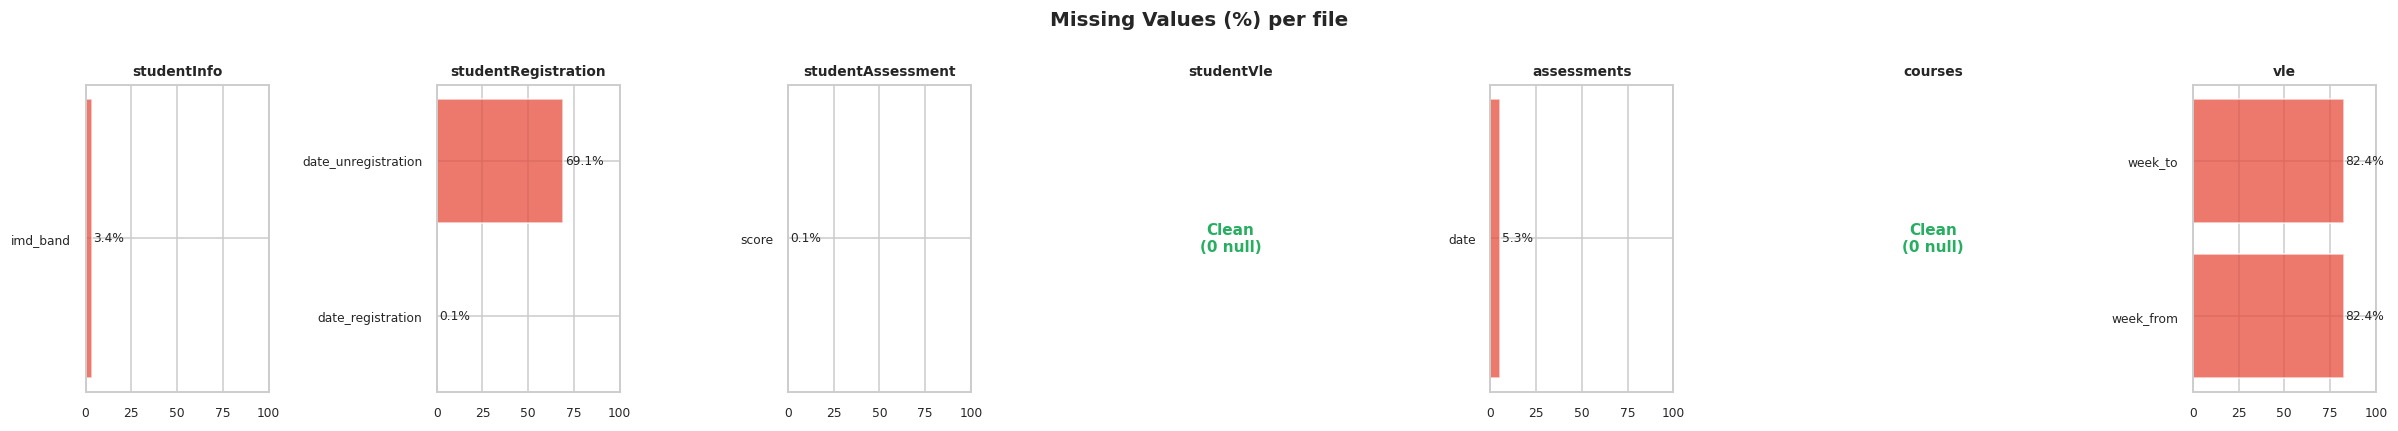

In [3]:
def section1_schema_overview():
    rows = []
    for f in REQUIRED:
        df = pd.read_csv(DATA_DIR / f)
        n_rows, n_cols = df.shape
        null_cols = df.columns[df.isnull().any()].tolist()
        null_pcts  = {c: f"{df[c].isnull().mean()*100:.1f}%" for c in null_cols}
        rows.append({
            'File': f,
            'Rows': f'{n_rows:,}',
            'Cols': n_cols,
            'Null Columns': ', '.join(f"{c} ({null_pcts[c]})" for c in null_cols) if null_cols else '—',
        })
    print('=== Schema Overview ===')
    print(pd.DataFrame(rows).set_index('File').to_string())

    # ── Missing heatmap per file ─────────────────────────────────────────
    fig, axes = plt.subplots(1, len(REQUIRED), figsize=(22, 4))
    for ax, f in zip(axes, REQUIRED):
        df   = pd.read_csv(DATA_DIR / f)
        miss = (df.isnull().mean() * 100).reset_index()
        miss.columns = ['Column', 'Missing %']
        miss = miss[miss['Missing %'] > 0]
        if miss.empty:
            ax.text(0.5, 0.5, 'Clean\n(0 null)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='#27ae60', fontweight='bold')
            ax.axis('off')
        else:
            bars = ax.barh(miss['Column'], miss['Missing %'], color='#e74c3c', alpha=0.75)
            ax.set_xlim(0, 100)
            for bar, val in zip(bars, miss['Missing %']):
                ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                        f'{val:.1f}%', va='center', fontsize=8)
        ax.set_title(f.replace('.csv',''), fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=8)
    plt.suptitle('Missing Values (%) per file', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section1_schema_overview()

---
## Section 2 — Semantic Null Analysis

> **Insight quan trọng nhất của EDA:** Null không phải lúc nào cũng là "thiếu data".
> Xử lý sai ở bước này = toàn bộ pipeline downstream bị ảnh hưởng.

| Column | Ý nghĩa thực | Xử lý đúng |
|--------|-------------|------------|
| `date_unregistration` = NULL | Sinh viên **không rút môn**, học đến cuối | **KHÔNG** dropna() |
| `date_unregistration` có giá trị | Sinh viên đã rút môn | Giữ nguyên |
| `score` = NULL | Sinh viên **không nộp bài** | `fillna(0)` — không nộp = 0 điểm |
| `imd_band` = NULL | Địa chỉ không map được vào vùng hành chính UK | Encode thành category `"Unknown"` |
| `week_from`, `week_to` = NULL (82.4%) | Resource available cả module | Drop cả 2 cột |
| `date` (assessments) = NULL (5.3%) | Không biết ngày deadline | Drop khi join |

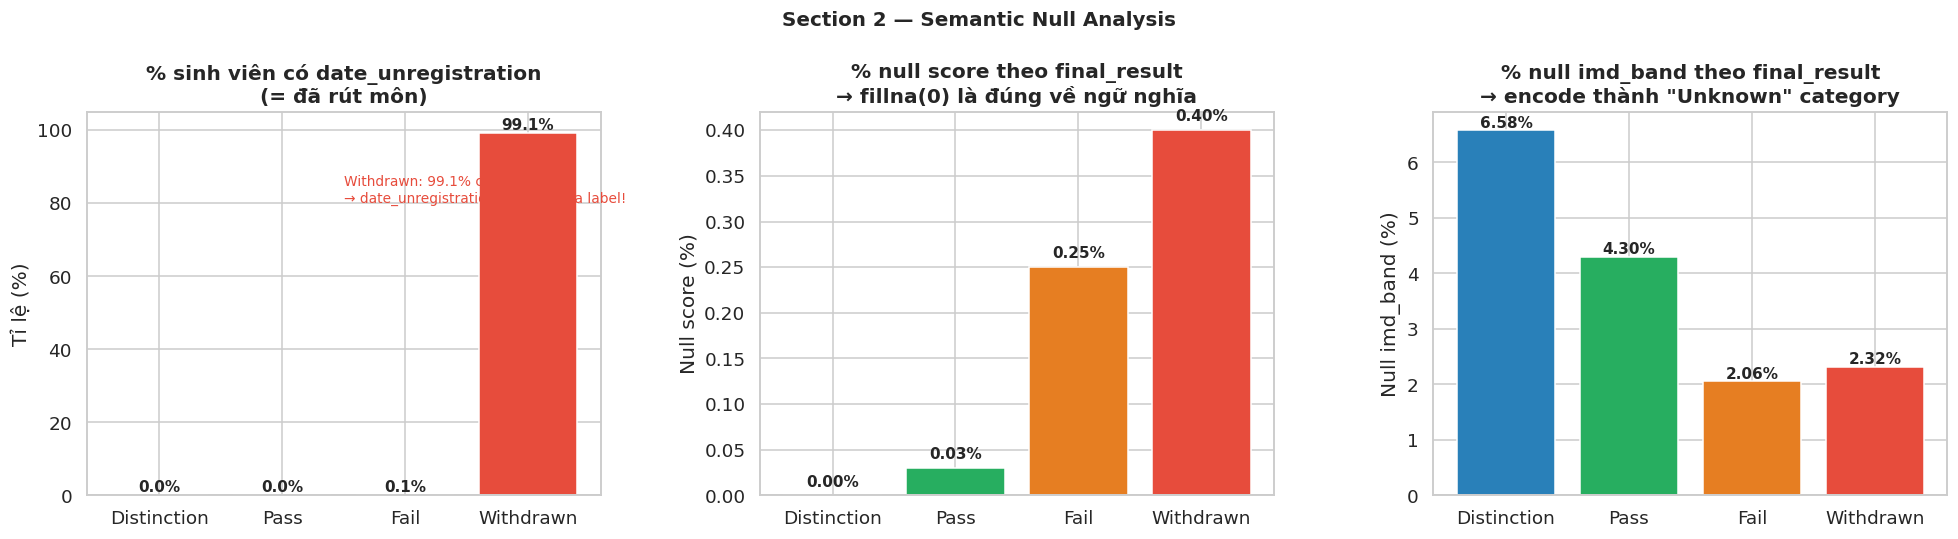

=== QUYẾT ĐỊNH XỬ LÝ NULL ===
  date_unregistration NULL → KHÔNG drop, NULL = "học đến cuối"
  date_unregistration có giá trị → KHÔNG dùng làm feature (leakage 100%!)
  score NULL → fillna(0), không nộp = 0 điểm
  imd_band NULL → encode "Unknown" category
  week_from/week_to NULL 82.4% → drop cả 2 cột


In [4]:
def section2_semantic_null():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_reg  = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
    df_sa   = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')

    merged_reg = df_reg.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    merged_reg['has_unreg'] = merged_reg['date_unregistration'].notna()

    # Null score by final_result
    merged_sa = df_sa.merge(df_info[['id_student','final_result']], on='id_student')
    null_by_result = (
        merged_sa.groupby('final_result')['score']
        .apply(lambda x: x.isna().mean() * 100).round(2)
        .reindex(RESULT_ORDER).reset_index()
        .rename(columns={'score': 'null_pct'})
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1: % has_unreg by result
    unreg_tbl = (
        merged_reg.groupby('final_result')['has_unreg']
        .mean().mul(100).round(1).reindex(RESULT_ORDER).reset_index()
    )
    colors_map = [RESULT_COLORS[r] for r in unreg_tbl['final_result']]
    bars = axes[0].bar(unreg_tbl['final_result'], unreg_tbl['has_unreg'],
                       color=colors_map, edgecolor='white')
    for bar, val in zip(bars, unreg_tbl['has_unreg']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
    axes[0].set_title('% sinh viên có date_unregistration\n(= đã rút môn)', fontweight='bold')
    axes[0].set_ylabel('Tỉ lệ (%)')
    axes[0].set_ylim(0, 105)
    axes[0].set_xlabel('')
    axes[0].annotate('Withdrawn: 99.1% có giá trị\n→ date_unregistration = proxy của label!',
                     xy=(3, unreg_tbl['has_unreg'].iloc[3]),
                     xytext=(1.5, 80), fontsize=9, color='#e74c3c',
                     arrowprops=dict(arrowstyle='->', color='#e74c3c'))

    # Chart 2: Null score % by result
    colors_map2 = [RESULT_COLORS[r] for r in null_by_result['final_result']]
    bars2 = axes[1].bar(null_by_result['final_result'], null_by_result['null_pct'],
                        color=colors_map2, edgecolor='white')
    for bar, val in zip(bars2, null_by_result['null_pct']):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)
    axes[1].set_title('% null score theo final_result\n→ fillna(0) là đúng về ngữ nghĩa', fontweight='bold')
    axes[1].set_ylabel('Null score (%)')
    axes[1].set_xlabel('')

    # Chart 3: imd_band null distribution
    df_info['imd_null'] = df_info['imd_band'].isna()
    imd_null_by_result = (
        df_info.groupby('final_result')['imd_null']
        .mean().mul(100).round(2).reindex(RESULT_ORDER).reset_index()
        .rename(columns={'imd_null': 'null_pct'})
    )
    colors_map3 = [RESULT_COLORS[r] for r in imd_null_by_result['final_result']]
    bars3 = axes[2].bar(imd_null_by_result['final_result'], imd_null_by_result['null_pct'],
                        color=colors_map3, edgecolor='white')
    for bar, val in zip(bars3, imd_null_by_result['null_pct']):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)
    axes[2].set_title('% null imd_band theo final_result\n→ encode thành "Unknown" category', fontweight='bold')
    axes[2].set_ylabel('Null imd_band (%)')
    axes[2].set_xlabel('')

    plt.suptitle('Section 2 — Semantic Null Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Decision log
    print('=== QUYẾT ĐỊNH XỬ LÝ NULL ===')
    print('  date_unregistration NULL → KHÔNG drop, NULL = "học đến cuối"')
    print('  date_unregistration có giá trị → KHÔNG dùng làm feature (leakage 100%!)')
    print('  score NULL → fillna(0), không nộp = 0 điểm')
    print('  imd_band NULL → encode "Unknown" category')
    print('  week_from/week_to NULL 82.4% → drop cả 2 cột')

section2_semantic_null()

---
## Section 3 — Target Variable + Demographic Analysis

### 3a. Phân phối target

| Label | Count | % | Ghi chú |
|-------|-------|---|---------|
| Pass | 12,361 | 37.9% | Nhóm lớn nhất |
| Withdrawn | 10,156 | 31.2% | **Quan trọng cho EWS** |
| Fail | 7,052 | 21.6% | — |
| Distinction | 3,024 | 9.3% | **Minority class — cần stratified split** |

### 3b. Signal của từng demographic feature

| Feature | Chi-square | Signal | Ghi chú |
|---------|-----------|--------|---------|
| `code_module` | Cao nhất | **Mạnh** | Distribution shift giữa modules |
| `highest_education` | Cao | Trung bình | HE Qual → pass tốt, Lower A Level → Withdrawn cao |
| `num_of_prev_attempts` | — | **Mạnh** | Monotonically negative — càng thi lại nhiều càng risk |
| `imd_band` | Trung bình | Trung bình | Vùng nghèo → At-Risk nhiều hơn |
| `age_band` | Trung bình | Trung bình | 0-35 Withdrawn cao nhất, 55+ Distinction cao nhất |
| `disability` | Thấp | Yếu | Không có diff lớn |
| `gender` | Thấp nhất | **Rất yếu** | Có thể drop |

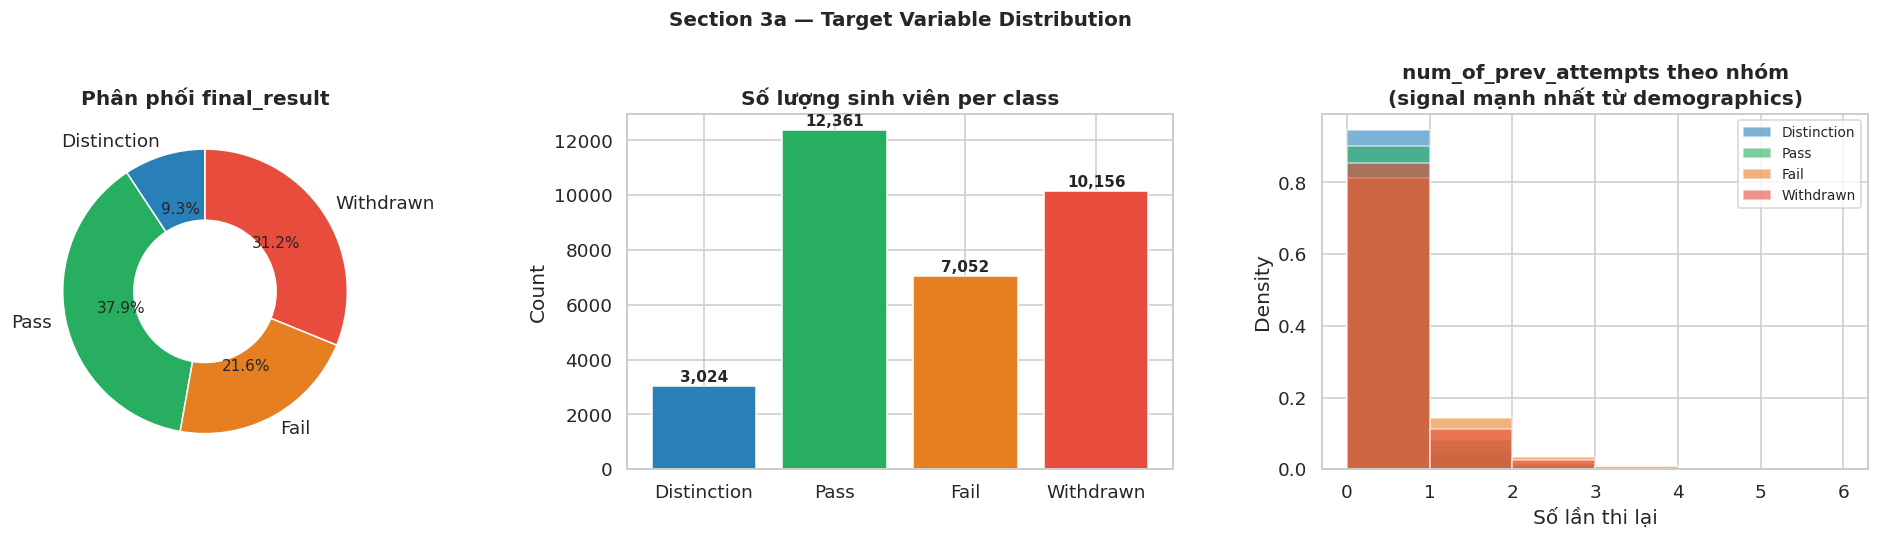

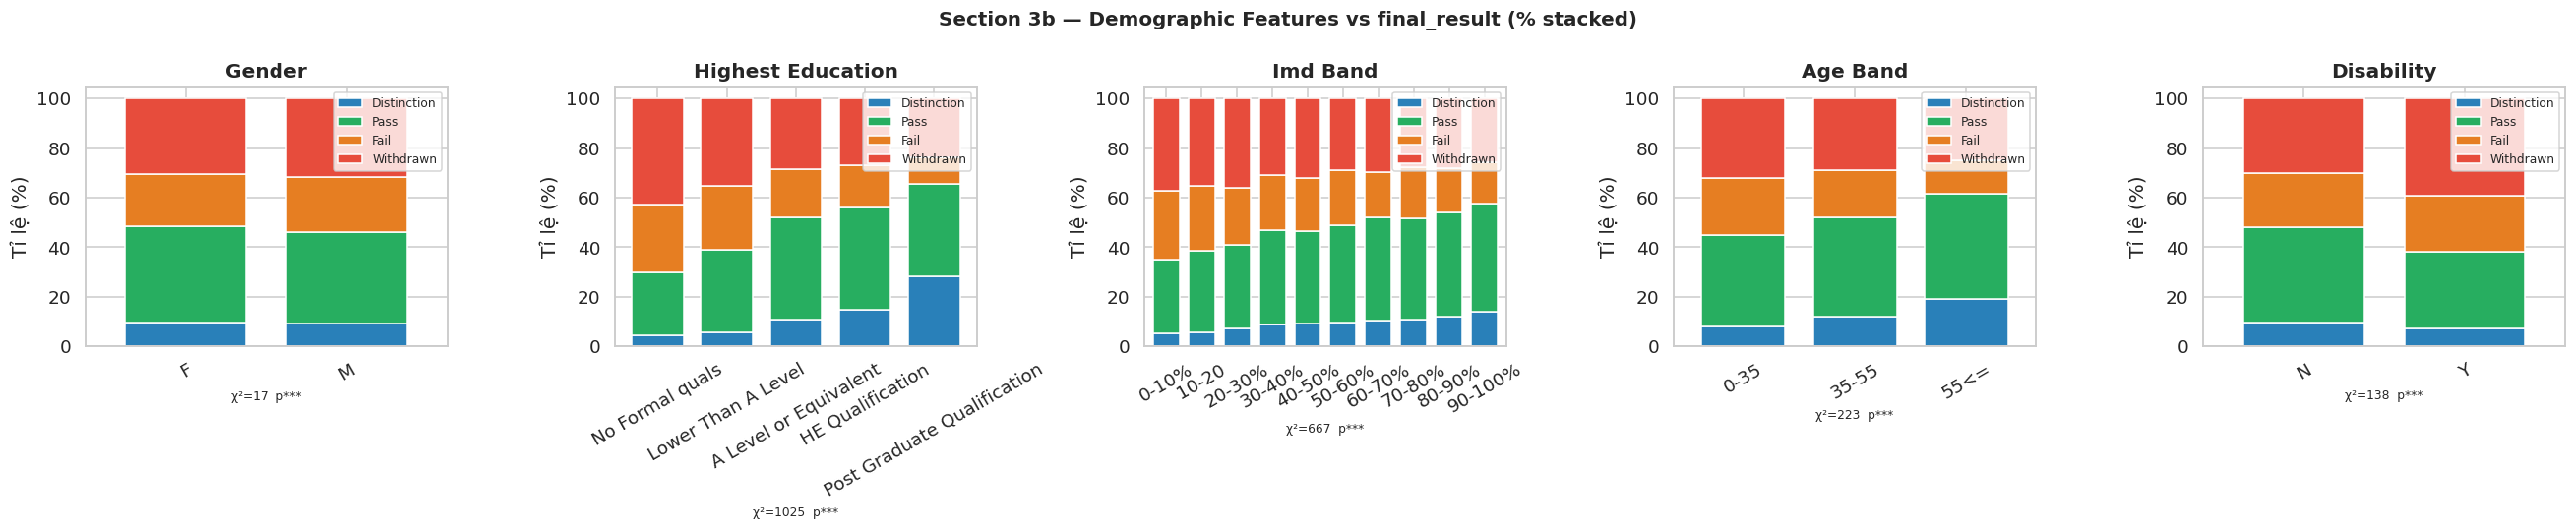


=== Chi-square ranking (demographics only) ===
  highest_education          χ²=  1024.7  p=9.18e-212  *** Mạnh
  imd_band                   χ²=   666.9  p=3.15e-123  *** Mạnh
  age_band                   χ²=   222.7  p=2.83e-45  *** Mạnh
  disability                 χ²=   138.5  p=8.14e-30  *** Mạnh
  gender                     χ²=    16.5  p=8.83e-04  *** Mạnh


In [5]:
def section3_target_analysis():
    df = pd.read_csv(DATA_DIR / 'studentInfo.csv')

    # ── Fig 1: Distribution ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    counts = df['final_result'].value_counts().reindex(RESULT_ORDER)

    # Donut
    wedges, texts, autotexts = axes[0].pie(
        counts, labels=counts.index, colors=RESULT_CLIST,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='white')
    )
    for at in autotexts:
        at.set_fontsize(10)
    axes[0].set_title('Phân phối final_result', fontweight='bold')

    # Bar count
    bars = axes[1].bar(RESULT_ORDER, counts.values, color=RESULT_CLIST, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[1].set_title('Số lượng sinh viên per class', fontweight='bold')
    axes[1].set_ylabel('Count')

    # num_of_prev_attempts
    for res, color in zip(RESULT_ORDER, RESULT_CLIST):
        subset = df[df['final_result'] == res]['num_of_prev_attempts']
        axes[2].hist(subset, bins=range(0, 7), alpha=0.6, label=res, color=color, density=True)
    axes[2].set_title('num_of_prev_attempts theo nhóm\n(signal mạnh nhất từ demographics)', fontweight='bold')
    axes[2].set_xlabel('Số lần thi lại')
    axes[2].set_ylabel('Density')
    axes[2].legend(fontsize=9)

    plt.suptitle('Section 3a — Target Variable Distribution', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Fig 2: Demographic profiles ───────────────────────────────────────
    demo_cols = ['gender', 'highest_education', 'imd_band', 'age_band', 'disability']
    edu_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                 'HE Qualification', 'Post Graduate Qualification']

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    orders = {
        'gender': None, 'highest_education': edu_order,
        'imd_band': sorted(df['imd_band'].dropna().unique()),
        'age_band': ['0-35', '35-55', '55<='],
        'disability': ['N', 'Y']
    }
    chi_results = []
    for ax, col in zip(axes, demo_cols):
        df_clean = df.dropna(subset=[col])
        plot_stacked_bar(df_clean, col, 'final_result',
                         col.replace('_', ' ').title(),
                         ax=ax, order=orders.get(col))
        chi2, p, _ = chi_square_test(df_clean, col, 'final_result')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
        ax.set_xlabel(f'χ²={chi2:.0f}  p{sig}', fontsize=8)
        chi_results.append({'feature': col, 'chi2': chi2, 'p_value': p})

    plt.suptitle('Section 3b — Demographic Features vs final_result (% stacked)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Chi-square ranking ─────────────────────────────────────────────────
    chi_df = pd.DataFrame(chi_results).sort_values('chi2', ascending=False)
    print('\n=== Chi-square ranking (demographics only) ===')
    for _, row in chi_df.iterrows():
        sig = '*** Mạnh' if row['p_value'] < 0.001 else 'Significant'
        print(f"  {row['feature']:<25}  χ²={row['chi2']:>8.1f}  p={row['p_value']:.2e}  {sig}")

section3_target_analysis()

---
## Section 4 — Assessment Analysis

### Score distribution & Submission timing

**Insight chính:**
- Withdrawn median score ~35, nhưng IQR rải rộng 0–70 → nhiều người bỏ học **không phải vì điểm kém** (lý do cá nhân: tài chính, công việc, gia đình)
- Sinh viên nộp bài **sớm hơn deadline** (days_before_deadline > 0) có kết quả tốt hơn
- `mean_score` cao hơn ngưỡng qua môn vì chỉ tính TMA/CMA — Exam cuối kỳ có trọng số lớn hơn nhưng điểm thấp hơn

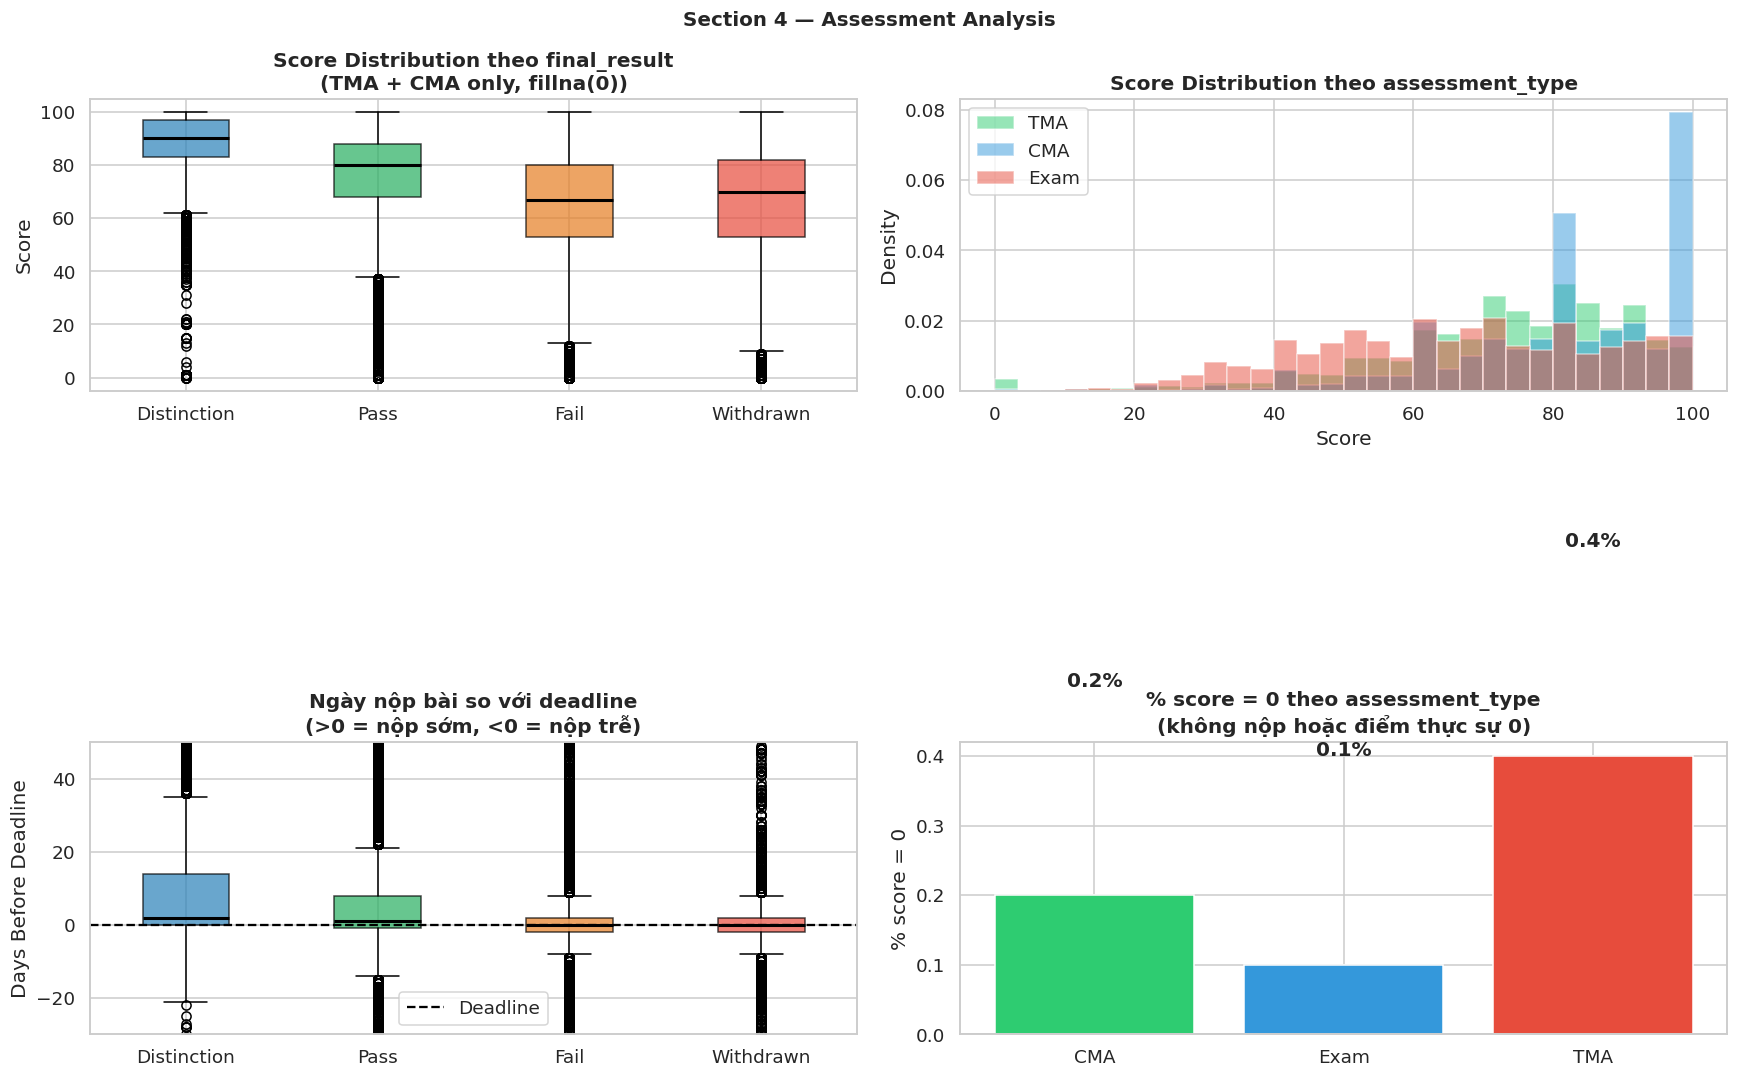

In [6]:
def section4_assessment_analysis():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_sa   = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')

    # Merge
    merged = (
        df_sa
        .merge(df_ass[['id_assessment','assessment_type','date','weight',
                        'code_module','code_presentation']], on='id_assessment', how='left')
        .merge(df_info[['id_student','code_module','code_presentation','final_result']],
               on=['id_student','code_module','code_presentation'], how='inner')
    )
    merged['score'] = merged['score'].fillna(0)
    merged['days_before_deadline'] = merged['date'] - merged['date_submitted']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Chart 1: Score boxplot by final_result
    merged_nonexam = merged[merged['assessment_type'] != 'Exam']
    data_by_result = [merged_nonexam[merged_nonexam['final_result'] == r]['score'].dropna()
                      for r in RESULT_ORDER]
    bp = axes[0][0].boxplot(data_by_result, labels=RESULT_ORDER, patch_artist=True,
                            medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], RESULT_CLIST):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0][0].set_title('Score Distribution theo final_result\n(TMA + CMA only, fillna(0))', fontweight='bold')
    axes[0][0].set_ylabel('Score')

    # Chart 2: Score boxplot by assessment_type
    for t, color in zip(['TMA', 'CMA', 'Exam'], ['#2ecc71', '#3498db', '#e74c3c']):
        sub = merged[merged['assessment_type'] == t]['score'].dropna()
        axes[0][1].hist(sub, bins=30, alpha=0.5, label=t, color=color, density=True)
    axes[0][1].set_title('Score Distribution theo assessment_type', fontweight='bold')
    axes[0][1].set_xlabel('Score')
    axes[0][1].set_ylabel('Density')
    axes[0][1].legend()

    # Chart 3: days_before_deadline boxplot
    data_days = [merged[merged['final_result'] == r]['days_before_deadline'].dropna()
                 for r in RESULT_ORDER]
    bp2 = axes[1][0].boxplot(data_days, labels=RESULT_ORDER, patch_artist=True,
                              medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp2['boxes'], RESULT_CLIST):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1][0].axhline(0, color='black', linestyle='--', linewidth=1.5, label='Deadline')
    axes[1][0].set_ylim(-30, 50)
    axes[1][0].set_title('Ngày nộp bài so với deadline\n(>0 = nộp sớm, <0 = nộp trễ)', fontweight='bold')
    axes[1][0].set_ylabel('Days Before Deadline')
    axes[1][0].legend()

    # Chart 4: submission rate by type
    type_counts = merged['assessment_type'].value_counts()
    null_by_type = (
        merged.groupby('assessment_type')['score']
        .apply(lambda x: (x == 0).mean() * 100).round(1)
        .rename('zero_score_pct').reset_index()
    )
    bars = axes[1][1].bar(null_by_type['assessment_type'], null_by_type['zero_score_pct'],
                          color=['#2ecc71', '#3498db', '#e74c3c'])
    for bar, val in zip(bars, null_by_type['zero_score_pct']):
        axes[1][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'{val:.1f}%', ha='center', fontweight='bold')
    axes[1][1].set_title('% score = 0 theo assessment_type\n(không nộp hoặc điểm thực sự 0)', fontweight='bold')
    axes[1][1].set_ylabel('% score = 0')

    plt.suptitle('Section 4 — Assessment Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section4_assessment_analysis()

---
## Section 5 — Module Structure Audit

> **Không thể so sánh raw score cross-module.** Cấu trúc đánh giá hoàn toàn khác nhau.

| Module | CMA count | Exam weight | TMA weight | Đặc điểm |
|--------|-----------|-------------|------------|----------|
| AAA | 0 | 200 | 200 | Không có CMA |
| BBB | 15 | 400 | 385 | Nặng TMA |
| GGG | 18 | 300 | **0** | TMA **không tính điểm** |
| FFF | 28 | 400 | 400 | CMA nhiều nhất |

**GGG đặc biệt:** TMA weight = 0 → feature `weighted_score_from_TMA` vô nghĩa với module này.

**Hướng xử lý:**
- `code_module` là categorical feature — để model tự học distribution shift
- Tính `weighted_score` đúng công thức, không dùng `mean(score)`
- Normalize: `cma_submission_rate = n_submitted / n_safe_cma_in_module` — AAA/EEE fillna(0)

=== Module Duration (ngày) ===
             min   mean  max
code_module                 
AAA          268  268.5  269
BBB          234  251.0  268
CCC          241  255.0  269
DDD          240  251.0  262
EEE          241  259.3  269
FFF          240  254.5  269
GGG          241  257.0  269

=== Assessment Count per Module x Type ===
assessment_type  CMA  Exam  TMA
code_module                    
AAA                0     2   10
BBB               15     4   23
CCC                8     4    8
DDD                7     4   24
EEE                0     3   12
FFF               28     4   20
GGG               18     3    9

=== Total Weight (%) per Module x Type ===
assessment_type   CMA   Exam    TMA
code_module                        
AAA               0.0  200.0  200.0
BBB              15.0  400.0  385.0
CCC              50.0  400.0  150.0
DDD              25.0  400.0  375.0
EEE               0.0  300.0  300.0
FFF               0.0  400.0  400.0
GGG               0.0  300.0    0.0

=== Pas

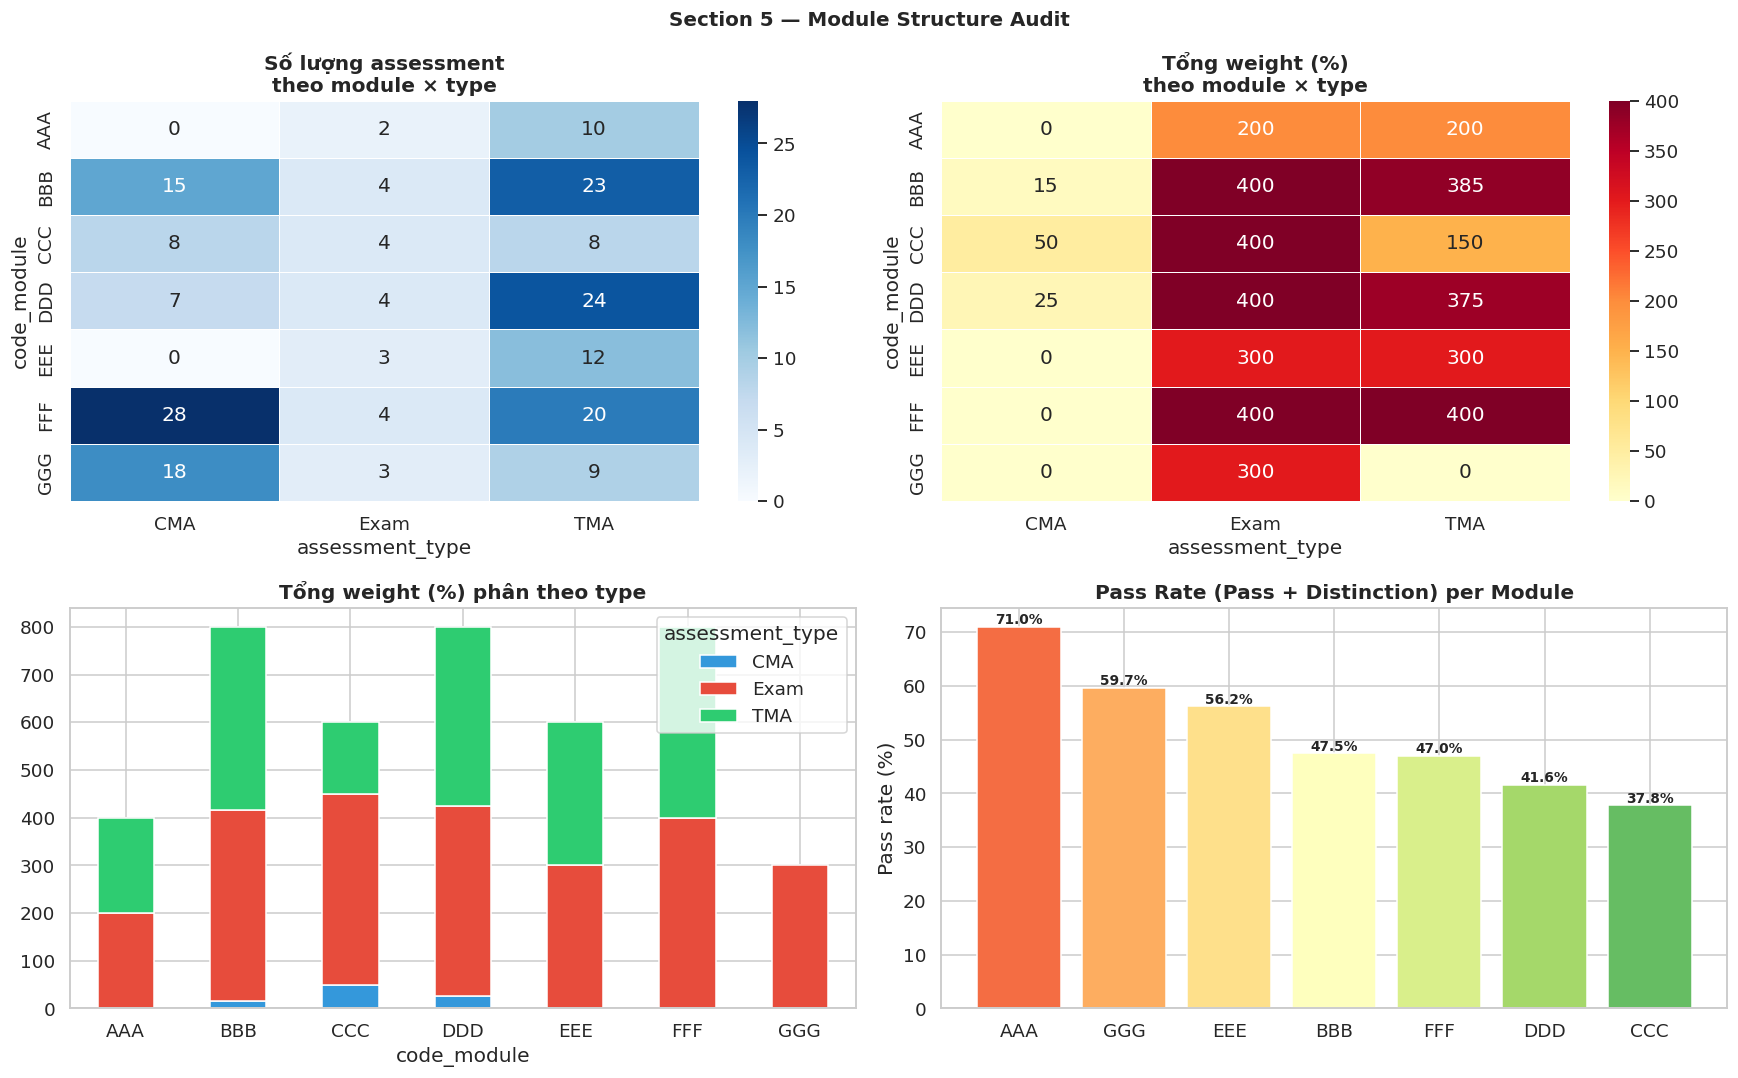

In [7]:
def section5_module_structure():
    df_ass = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_crs = pd.read_csv(DATA_DIR / 'courses.csv')
    df_info= pd.read_csv(DATA_DIR / 'studentInfo.csv')

    dur          = df_crs.groupby('code_module')['module_presentation_length'].agg(['min','mean','max']).round(1)
    pivot_count  = df_ass.groupby(['code_module','assessment_type'])['id_assessment'].count().unstack(fill_value=0)
    pivot_weight = df_ass.groupby(['code_module','assessment_type'])['weight'].sum().unstack(fill_value=0)
    pass_rate    = (
        df_info.assign(is_pass=lambda x: x['final_result'].isin(['Pass','Distinction']).astype(int))
        .groupby('code_module')['is_pass'].mean().mul(100).round(1)
        .rename('pass_rate_%')
    )

    print('=== Module Duration (ngày) ===')
    print(dur)
    print('\n=== Assessment Count per Module x Type ===')
    print(pivot_count)
    print('\n=== Total Weight (%) per Module x Type ===')
    print(pivot_weight)
    print('\n=== Pass Rate per Module ===')
    print(pass_rate)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.heatmap(pivot_count, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=axes[0][0])
    axes[0][0].set_title('Số lượng assessment\ntheo module × type', fontweight='bold')

    sns.heatmap(pivot_weight, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, ax=axes[0][1])
    axes[0][1].set_title('Tổng weight (%)\ntheo module × type', fontweight='bold')

    type_colors = {'CMA':'#3498db', 'Exam':'#e74c3c', 'TMA':'#2ecc71'}
    pivot_weight.plot(kind='bar', stacked=True, ax=axes[1][0],
                      color=[type_colors.get(t,'gray') for t in pivot_weight.columns],
                      edgecolor='white')
    axes[1][0].set_title('Tổng weight (%) phân theo type', fontweight='bold')
    axes[1][0].tick_params(axis='x', rotation=0)

    pass_rate_sorted = pass_rate.sort_values(ascending=False)
    colors_module    = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(pass_rate_sorted)))
    bars = axes[1][1].bar(pass_rate_sorted.index, pass_rate_sorted.values, color=colors_module)
    for bar, val in zip(bars, pass_rate_sorted.values):
        axes[1][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[1][1].set_title('Pass Rate (Pass + Distinction) per Module', fontweight='bold')
    axes[1][1].set_ylabel('Pass rate (%)')

    plt.suptitle('Section 5 — Module Structure Audit', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section5_module_structure()

---
## Section 6 — Presentation Effect (B vs J)

Kỳ **B** (tháng 2) và kỳ **J** (tháng 10) có pass rate khác nhau.

| Semester | Pass rate | n_students |
|----------|-----------|-----------|
| B (Feb) | 43.67% | 12,488 |
| J (Oct) | 49.40% | 20,105 |

Chênh lệch **không đồng đều giữa modules** (CCC và EEE chênh >6pp) → `semester` phải là feature.

```python
# Feature engineering
df['semester'] = df['code_presentation'].str[-1]          # 'B' hoặc 'J'
df['module_semester'] = df['code_module'] + '_' + df['semester']  # interaction term
```

=== Pass rate theo semester ===
          pass_rate  n_students
semester                       
B             43.67       12488
J             49.40       20105

=== Pass rate per module x semester ===
semester         B      J  diff_B_minus_J
code_module                              
AAA            NaN  70.99             NaN
BBB          45.27  49.11           -3.84
CCC          34.25  40.63           -6.38
DDD          39.08  43.33           -4.25
EEE          51.44  57.72           -6.28
FFF          46.11  47.59           -1.48
GGG          57.38  60.91           -3.53


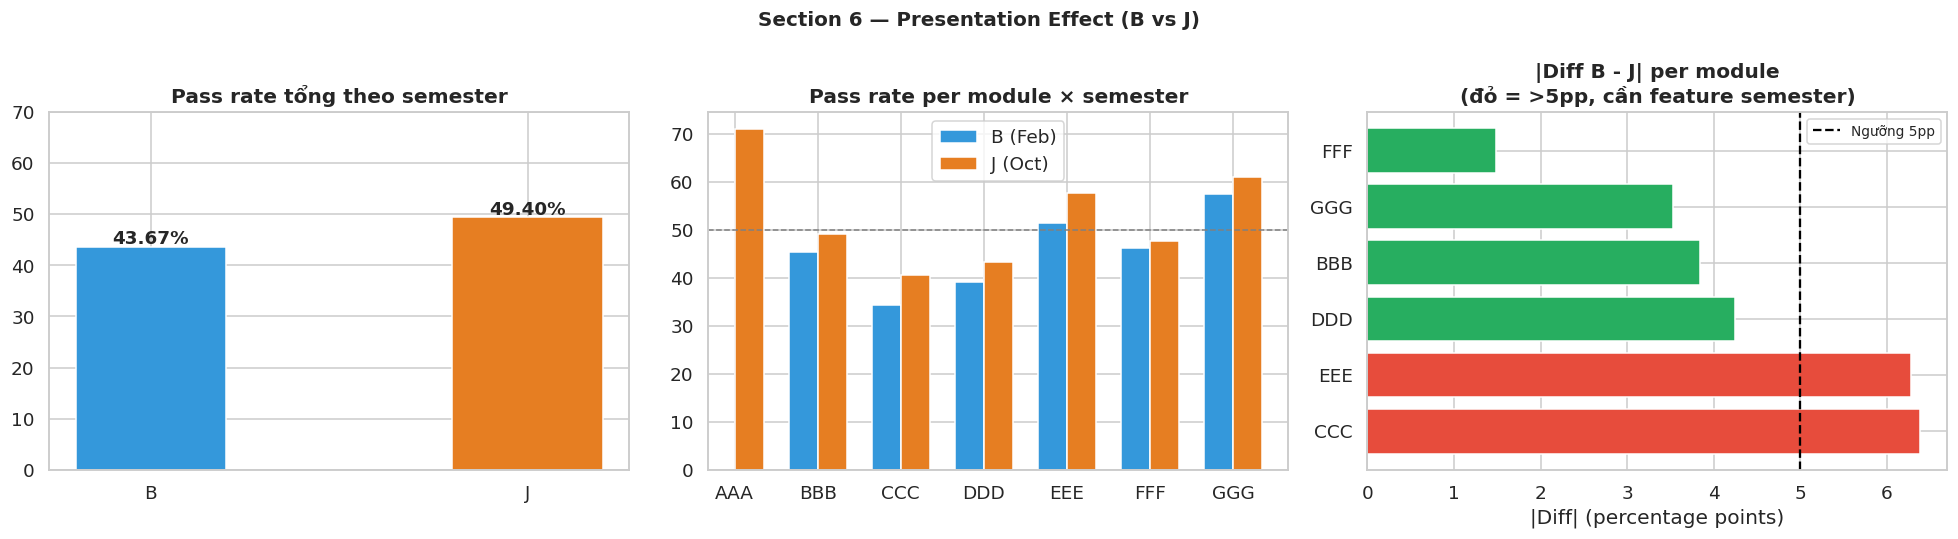

In [8]:
def section6_presentation_effect():
    df = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df['semester'] = df['code_presentation'].str[-1]
    df['is_pass']  = df['final_result'].isin(['Pass','Distinction']).astype(int)

    overall = (
        df.groupby('semester')['is_pass']
        .agg(['mean','count'])
        .rename(columns={'mean':'pass_rate','count':'n_students'})
    )
    overall['pass_rate'] = overall['pass_rate'].mul(100).round(2)

    per_module = (
        df.groupby(['code_module','semester'])['is_pass']
        .mean().mul(100).round(2).unstack()
    )
    if 'B' in per_module.columns and 'J' in per_module.columns:
        per_module['diff_B_minus_J'] = (per_module['B'] - per_module['J']).round(2)

    print('=== Pass rate theo semester ===')
    print(overall)
    print('\n=== Pass rate per module x semester ===')
    print(per_module.to_string())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sem_colors = {'B':'#3498db','J':'#e67e22'}
    bars = axes[0].bar(overall.index, overall['pass_rate'],
                       color=[sem_colors.get(s,'gray') for s in overall.index],
                       width=0.4, edgecolor='white')
    for bar, val in zip(bars, overall['pass_rate']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.2f}%', ha='center', fontweight='bold', fontsize=12)
    axes[0].set_title('Pass rate tổng theo semester', fontweight='bold')
    axes[0].set_ylim(0, 70)

    if 'B' in per_module.columns and 'J' in per_module.columns:
        x = np.arange(len(per_module))
        w = 0.35
        axes[1].bar(x - w/2, per_module['B'], w, label='B (Feb)', color='#3498db', edgecolor='white')
        axes[1].bar(x + w/2, per_module['J'], w, label='J (Oct)', color='#e67e22', edgecolor='white')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(per_module.index)
        axes[1].set_title('Pass rate per module × semester', fontweight='bold')
        axes[1].legend()
        axes[1].axhline(50, color='gray', linestyle='--', linewidth=1)

        diff_abs = per_module['diff_B_minus_J'].abs().sort_values(ascending=False)
        colors_diff = ['#e74c3c' if abs(v) > 5 else '#27ae60' for v in diff_abs]
        bars3 = axes[2].barh(diff_abs.index, diff_abs.values, color=colors_diff)
        axes[2].axvline(5, color='black', linestyle='--', linewidth=1.5, label='Ngưỡng 5pp')
        axes[2].set_title('|Diff B - J| per module\n(đỏ = >5pp, cần feature semester)', fontweight='bold')
        axes[2].set_xlabel('|Diff| (percentage points)')
        axes[2].legend(fontsize=9)

    plt.suptitle('Section 6 — Presentation Effect (B vs J)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section6_presentation_effect()

---
## Section 7 — Data-Driven Cut-off Selection

Cut-off day là tham số quan trọng nhất của Early Warning System.
**Phải chọn từ data**, không được assume.

**Logic:** Chọn cut-off nhỏ nhất sao cho:
- Capture ≥ 80% Withdrawn (đủ để train model nhận biết Withdrawn)
- Còn đủ thời gian can thiệp sau cut-off

**Kết quả: cut-off = day 135** (~50% module length)
- Capture ~80% Withdrawn
- Còn ~126 ngày để can thiệp

Median module length : 262 ngày
Cut-off ≥80% Withdrawn: day 135 (51.6% module)
Cut-off ≥90% Withdrawn: day 175 (66.9% module)

→ Chọn CUTOFF_DAY = 135 (≥80%, còn 48% module để can thiệp)


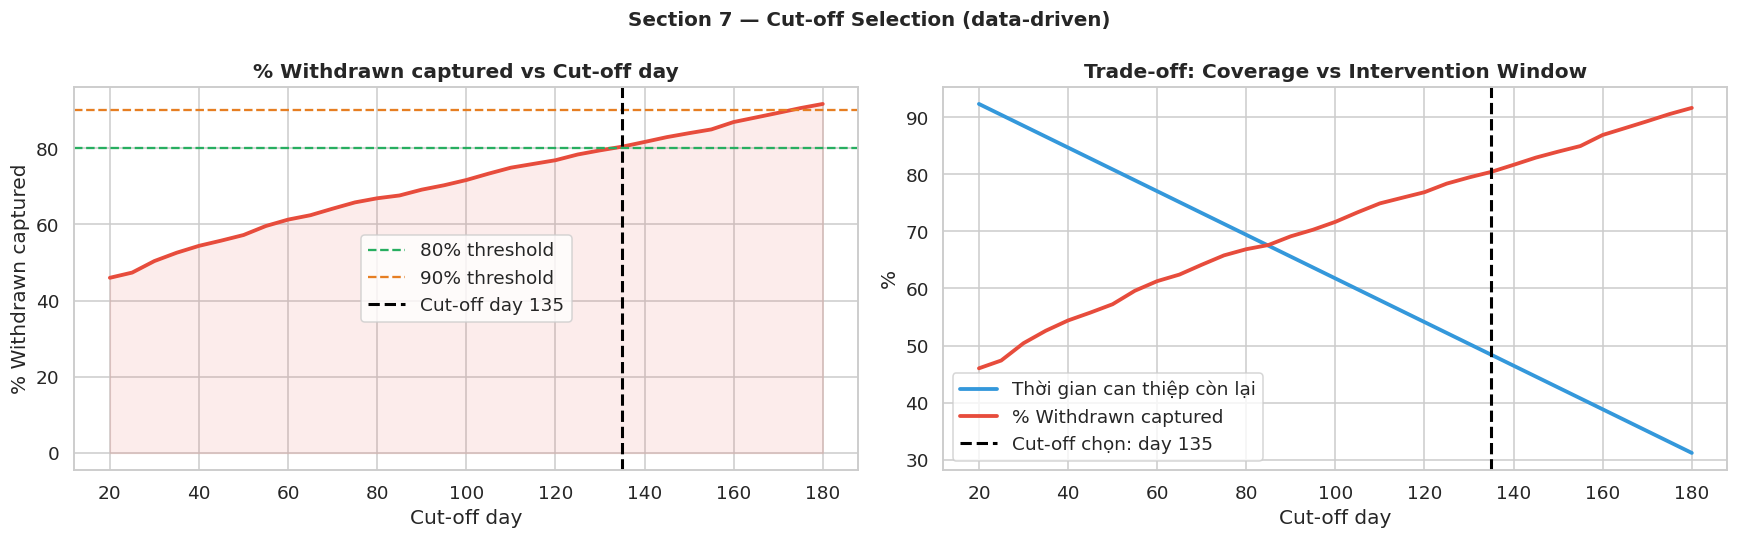

In [9]:
def section7_cutoff_selection():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_reg  = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
    df_crs  = pd.read_csv(DATA_DIR / 'courses.csv')

    merged = (
        df_reg
        .merge(df_info[['code_module','code_presentation','id_student','final_result']],
               on=['code_module','code_presentation','id_student'], how='inner')
        .merge(df_crs, on=['code_module','code_presentation'], how='left')
    )

    withdrawn = merged[merged['final_result'] == 'Withdrawn'].copy()
    total_w   = len(withdrawn)
    med_len   = df_crs['module_presentation_length'].median()

    cutoffs = range(20, 181, 5)
    records = []
    for c in cutoffs:
        n_captured = (withdrawn['date_unregistration'] <= c).sum()
        records.append({
            'cutoff_day': c,
            'pct_withdrawn': n_captured / total_w * 100,
            'remaining_pct': (1 - c / med_len) * 100,
        })
    df_co = pd.DataFrame(records)

    co_80 = df_co[df_co['pct_withdrawn'] >= 80]['cutoff_day'].min()
    co_90 = df_co[df_co['pct_withdrawn'] >= 90]['cutoff_day'].min()

    print(f'Median module length : {med_len:.0f} ngày')
    print(f'Cut-off ≥80% Withdrawn: day {co_80} ({co_80/med_len*100:.1f}% module)')
    print(f'Cut-off ≥90% Withdrawn: day {co_90} ({co_90/med_len*100:.1f}% module)')
    print(f'\n→ Chọn CUTOFF_DAY = {CUTOFF_DAY} (≥80%, còn {100-CUTOFF_DAY/med_len*100:.0f}% module để can thiệp)')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(df_co['cutoff_day'], df_co['pct_withdrawn'],
                 color='#e74c3c', linewidth=2.5)
    axes[0].axhline(80, color='#27ae60', linestyle='--', linewidth=1.5, label='80% threshold')
    axes[0].axhline(90, color='#e67e22', linestyle='--', linewidth=1.5, label='90% threshold')
    axes[0].axvline(CUTOFF_DAY, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off day {CUTOFF_DAY}')
    axes[0].fill_between(df_co['cutoff_day'], df_co['pct_withdrawn'], alpha=0.1, color='#e74c3c')
    axes[0].set_title('% Withdrawn captured vs Cut-off day', fontweight='bold')
    axes[0].set_xlabel('Cut-off day')
    axes[0].set_ylabel('% Withdrawn captured')
    axes[0].legend()

    axes[1].plot(df_co['cutoff_day'], df_co['remaining_pct'],
                 color='#3498db', linewidth=2.5, label='Thời gian can thiệp còn lại')
    axes[1].plot(df_co['cutoff_day'], df_co['pct_withdrawn'],
                 color='#e74c3c', linewidth=2.5, label='% Withdrawn captured')
    axes[1].axvline(CUTOFF_DAY, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off chọn: day {CUTOFF_DAY}')
    axes[1].set_title('Trade-off: Coverage vs Intervention Window', fontweight='bold')
    axes[1].set_xlabel('Cut-off day')
    axes[1].set_ylabel('%')
    axes[1].legend()

    plt.suptitle('Section 7 — Cut-off Selection (data-driven)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section7_cutoff_selection()

---
## Section 8 — Leakage Audit (tại cut-off = day 135)

**Dùng toàn bộ `studentAssessment` = data leakage.** Exam cuối kỳ luôn xảy ra sau cut-off.

| Type | SAFE (≤135) | LEAKAGE (>135) | Quyết định |
|------|-------------|-----------------|-----------|
| TMA | **71** | 35 | ✅ Dùng — majority safe |
| CMA | 17 | **59** | ⚠️ Dùng thận trọng — normalize per module |
| Exam | 0 | **6** | ❌ Không dùng tuyệt đối |

**Lỗi phổ biến với CMA:**
```python
# SAI — đếm tuyệt đối
n_cma_submitted = 3

# ĐÚNG — tỉ lệ so với available trong module tại cut-off
cma_submission_rate = n_submitted / n_safe_cma_available_in_module
# AAA/EEE không có CMA → fillna(0) hoặc -1
```

=== Assessment SAFE vs LEAKAGE at cut-off day 135 ===
is_safe          LEAKAGE  SAFE (≤day 135)
assessment_type                          
CMA                   59               17
Exam                   6                0
TMA                   35               71

=== Submit ratio stats ===
                   count   mean    std    min    25%    50%    75%    max
assessment_type                                                          
CMA              70527.0  0.546  0.280 -0.033  0.286  0.577  0.804  2.475
Exam              4959.0  0.935  0.025  0.903  0.908  0.927  0.954  1.104
TMA              98426.0  0.366  0.238 -0.047  0.158  0.353  0.565  1.075


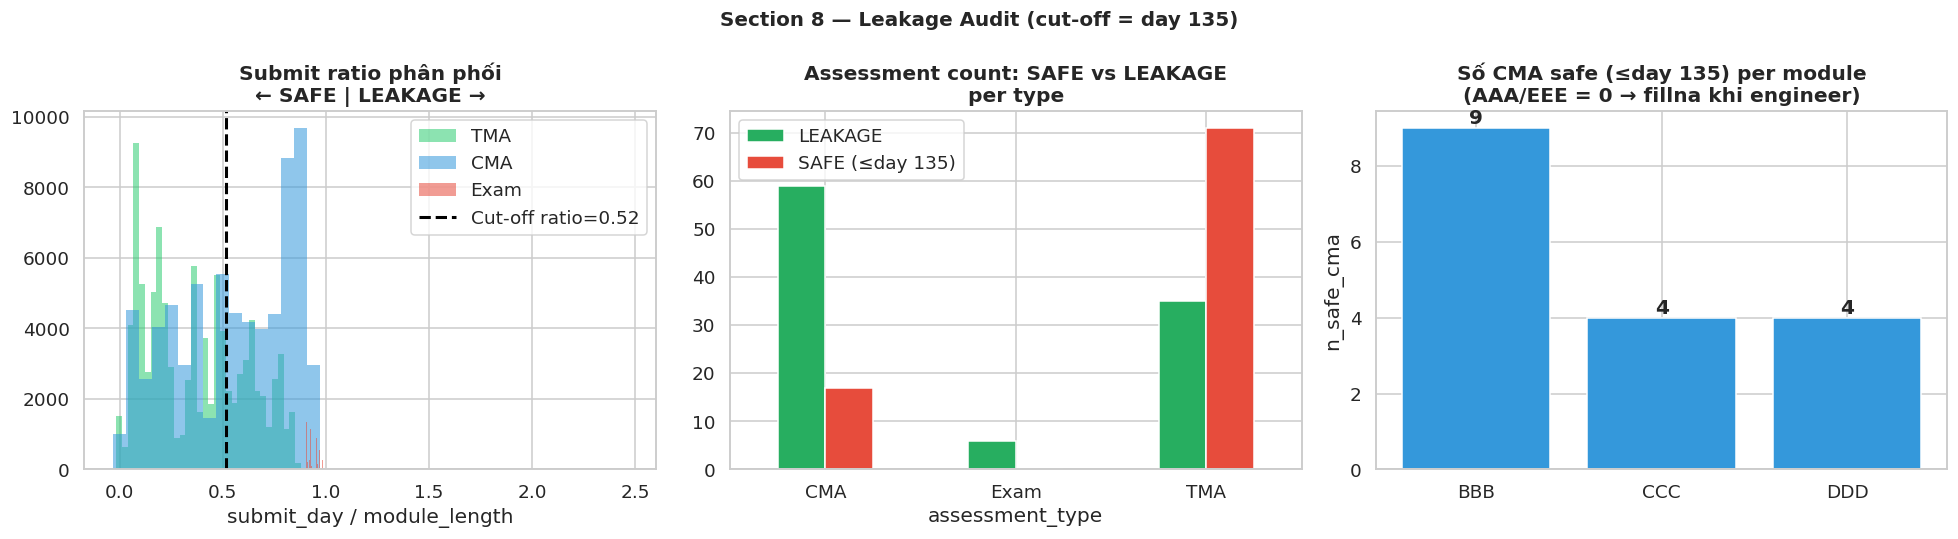

In [10]:
def section8_leakage_audit(cutoff_day=CUTOFF_DAY):
    df_sa  = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_crs = pd.read_csv(DATA_DIR / 'courses.csv')

    merged = (
        df_sa
        .merge(df_ass, on='id_assessment')
        .merge(df_crs, on=['code_module','code_presentation'])
    )
    merged['submit_ratio']   = merged['date_submitted'] / merged['module_presentation_length']
    merged['deadline_ratio'] = merged['date']           / merged['module_presentation_length']
    merged['is_safe']        = merged['date'] <= cutoff_day

    safe_tbl = (
        merged.groupby(['assessment_type','is_safe'])['id_assessment']
        .nunique().unstack(fill_value=0)
        .rename(columns={True: f'SAFE (≤day {cutoff_day})', False: 'LEAKAGE'})
    )
    print(f'=== Assessment SAFE vs LEAKAGE at cut-off day {cutoff_day} ===')
    print(safe_tbl)
    print('\n=== Submit ratio stats ===')
    print(merged.groupby('assessment_type')['submit_ratio'].describe().round(3))

    type_colors = {'CMA':'#3498db', 'Exam':'#e74c3c', 'TMA':'#2ecc71'}
    cutoff_ratio = cutoff_day / df_crs['module_presentation_length'].median()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1: submit_ratio histogram
    for t in ['TMA', 'CMA', 'Exam']:
        sub = merged[merged['assessment_type'] == t]['submit_ratio'].dropna()
        axes[0].hist(sub, bins=40, alpha=0.55, label=t,
                     color=type_colors[t], edgecolor='none')
    axes[0].axvline(cutoff_ratio, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off ratio={cutoff_ratio:.2f}')
    axes[0].set_title(f'Submit ratio phân phối\n← SAFE | LEAKAGE →', fontweight='bold')
    axes[0].set_xlabel('submit_day / module_length')
    axes[0].legend()

    # Chart 2: safe count stacked
    safe_tbl.plot(kind='bar', stacked=False, ax=axes[1],
                  color=['#27ae60','#e74c3c'], edgecolor='white')
    axes[1].set_title('Assessment count: SAFE vs LEAKAGE\nper type', fontweight='bold')
    axes[1].set_xticklabels(safe_tbl.index, rotation=0)
    axes[1].legend()

    # Chart 3: safe CMA per module
    safe_cma = (
        merged[(merged['assessment_type'] == 'CMA') & (merged['is_safe'])]
        .groupby('code_module')['id_assessment'].nunique()
        .reset_index().rename(columns={'id_assessment': 'n_safe_cma'})
    )
    bars = axes[2].bar(safe_cma['code_module'], safe_cma['n_safe_cma'],
                       color='#3498db', edgecolor='white')
    for bar, val in zip(bars, safe_cma['n_safe_cma']):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     str(val), ha='center', fontweight='bold')
    axes[2].set_title(f'Số CMA safe (≤day {cutoff_day}) per module\n(AAA/EEE = 0 → fillna khi engineer)', fontweight='bold')
    axes[2].set_ylabel('n_safe_cma')

    plt.suptitle(f'Section 8 — Leakage Audit (cut-off = day {cutoff_day})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section8_leakage_audit()

---
## Section 9 — VLE Time-series Analysis

> **Core argument:** `sum_click` tổng là feature kém.
> 1000 clicks ngày 1 rồi biến mất ≠ 10 clicks/ngày đều trong 100 ngày.

**Temporal features cần tạo (tất cả chỉ tính trong ≤ cut-off):**
```python
active_days          # số ngày có ≥1 click
clicks_per_week_1..N # clicks từng tuần  
last_active_day      # recency — Withdrawn dừng sớm = feature mạnh
std_clicks           # độ đều đặn
clicks_by_activity   # oucontent, forumng, quiz — high-signal
```

**Patterns quan sát được:**
- **Withdrawn:** dense activity đầu khóa → dừng đột ngột trước cut-off
- **Fail:** "nước tới chân mới nhảy" — spike cuối kỳ nhưng quá muộn  
- **Distinction/Pass:** activity đều đặn suốt module, tăng nhẹ quanh deadline

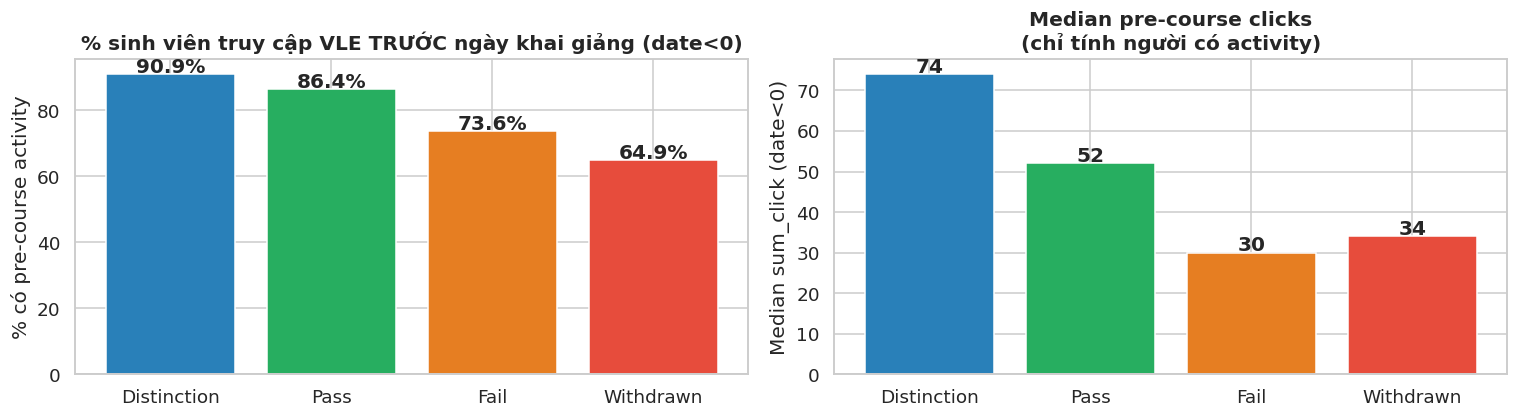

pre_clicks  : ρ=+0.2684  p=0.00e+00
pre_days    : ρ=+0.2471  p=0.00e+00
has_pre     : ρ=+0.2361  p=0.00e+00


In [11]:
# Section 9.0 — Pre-course activity check
df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
df_vle = pd.read_csv(DATA_DIR / 'studentVle.csv')
vle = df_vle.merge(
    df_info[['code_module','code_presentation','id_student','final_result']],
    on=['code_module','code_presentation','id_student'], how='inner'
)

pre = (vle[vle['date'] < 0]
       .groupby(['id_student','final_result'])
       .agg(pre_clicks=('sum_click','sum'),
            pre_days=('date','nunique'))
       .reset_index())

# Merge với toàn bộ student để có cả người KHÔNG có pre-activity
all_students = df_info[['id_student','final_result']].drop_duplicates()
pre_full = all_students.merge(pre[['id_student','pre_clicks','pre_days']],
                               on='id_student', how='left').fillna(0)
pre_full['has_pre'] = (pre_full['pre_days'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Chart 1: % sinh viên có pre-course activity theo final_result
pct = pre_full.groupby('final_result')['has_pre'].mean().mul(100).reindex(RESULT_ORDER)
bars = axes[0].bar(pct.index, pct.values, color=RESULT_CLIST, edgecolor='white')
for b, v in zip(bars, pct.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('% sinh viên truy cập VLE TRƯỚC ngày khai giảng (date<0)', fontweight='bold')
axes[0].set_ylabel('% có pre-course activity')

# Chart 2: Median pre_clicks (chỉ tính người CÓ activity)
active = pre_full[pre_full['has_pre']==1]
med = active.groupby('final_result')['pre_clicks'].median().reindex(RESULT_ORDER)
axes[1].bar(med.index, med.values, color=RESULT_CLIST, edgecolor='white')
for x, v in enumerate(med.values):
    axes[1].text(x, v+0.5, f'{v:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Median pre-course clicks\n(chỉ tính người có activity)', fontweight='bold')
axes[1].set_ylabel('Median sum_click (date<0)')

plt.tight_layout(); plt.show()

# Spearman
from scipy.stats import spearmanr
y = pre_full['final_result'].map({'Distinction':3,'Pass':2,'Fail':1,'Withdrawn':0})
for col in ['pre_clicks','pre_days','has_pre']:
    rho, p = spearmanr(pre_full[col], y)
    print(f'{col:12s}: ρ={rho:+.4f}  p={p:.2e}')

Loading studentVle.csv...


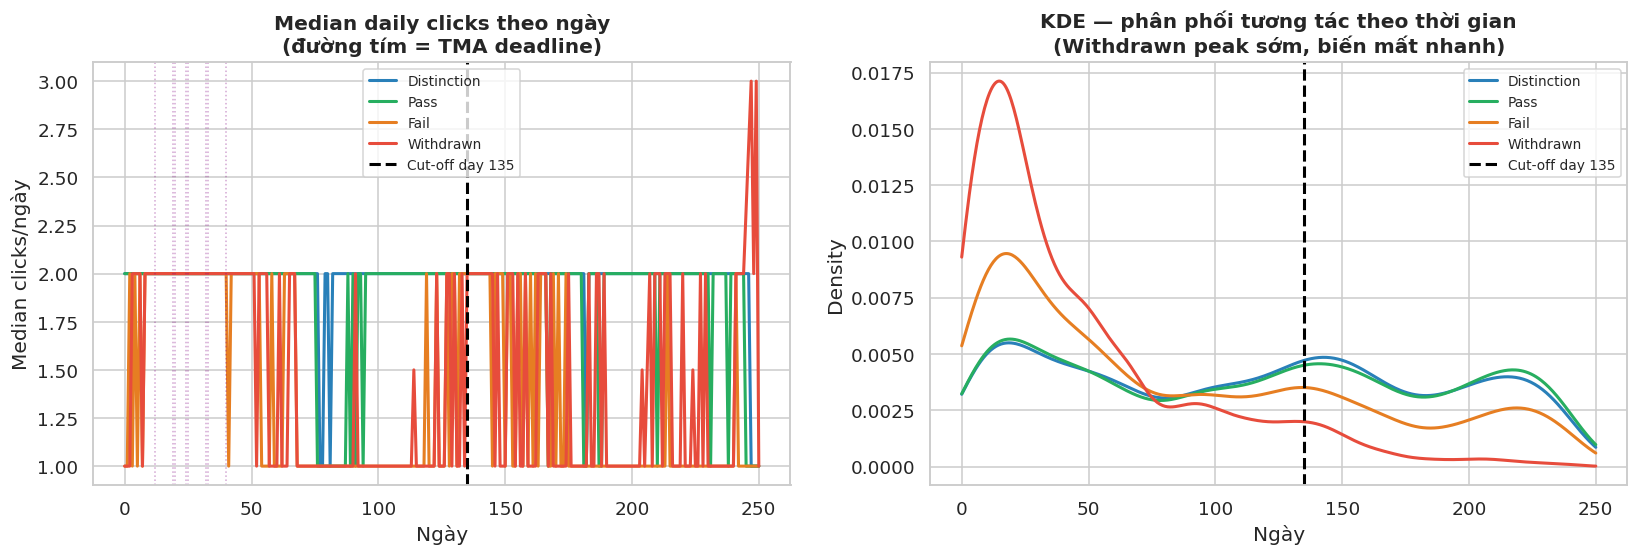

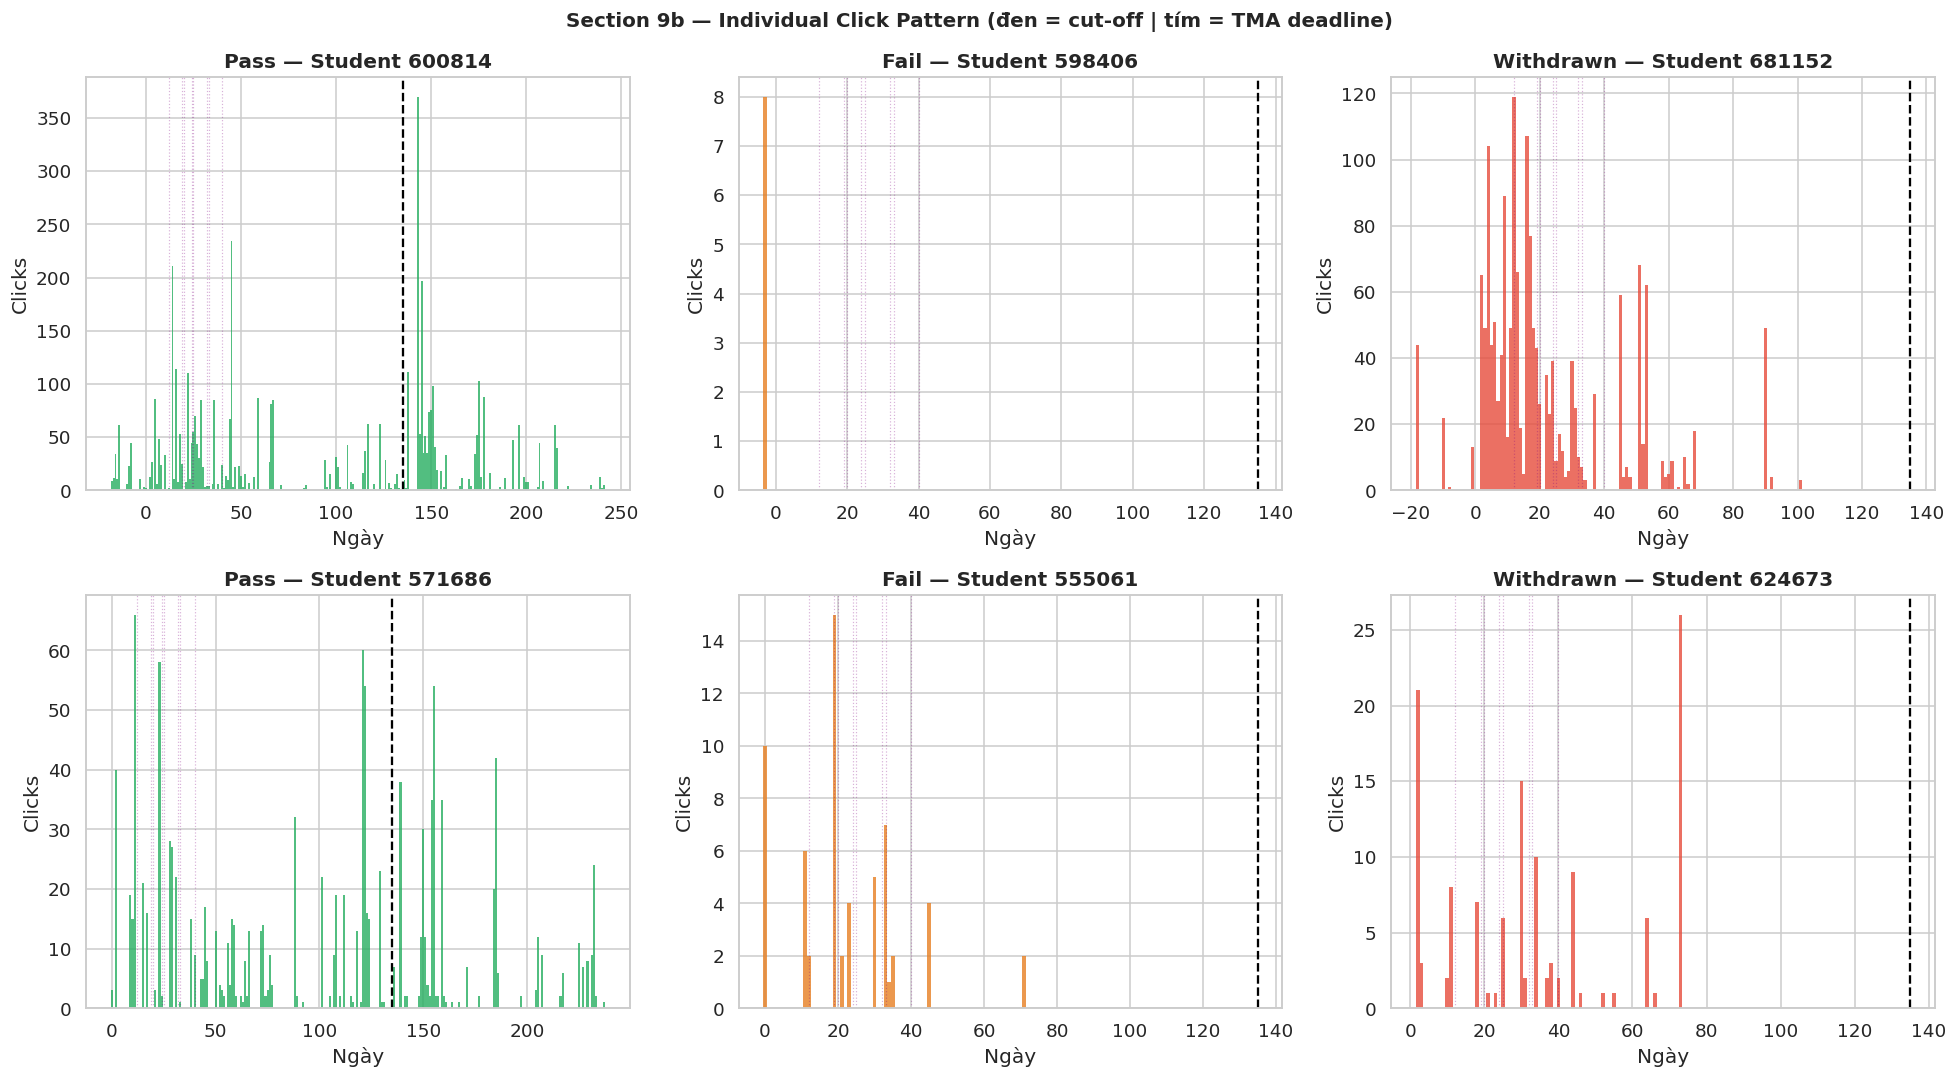

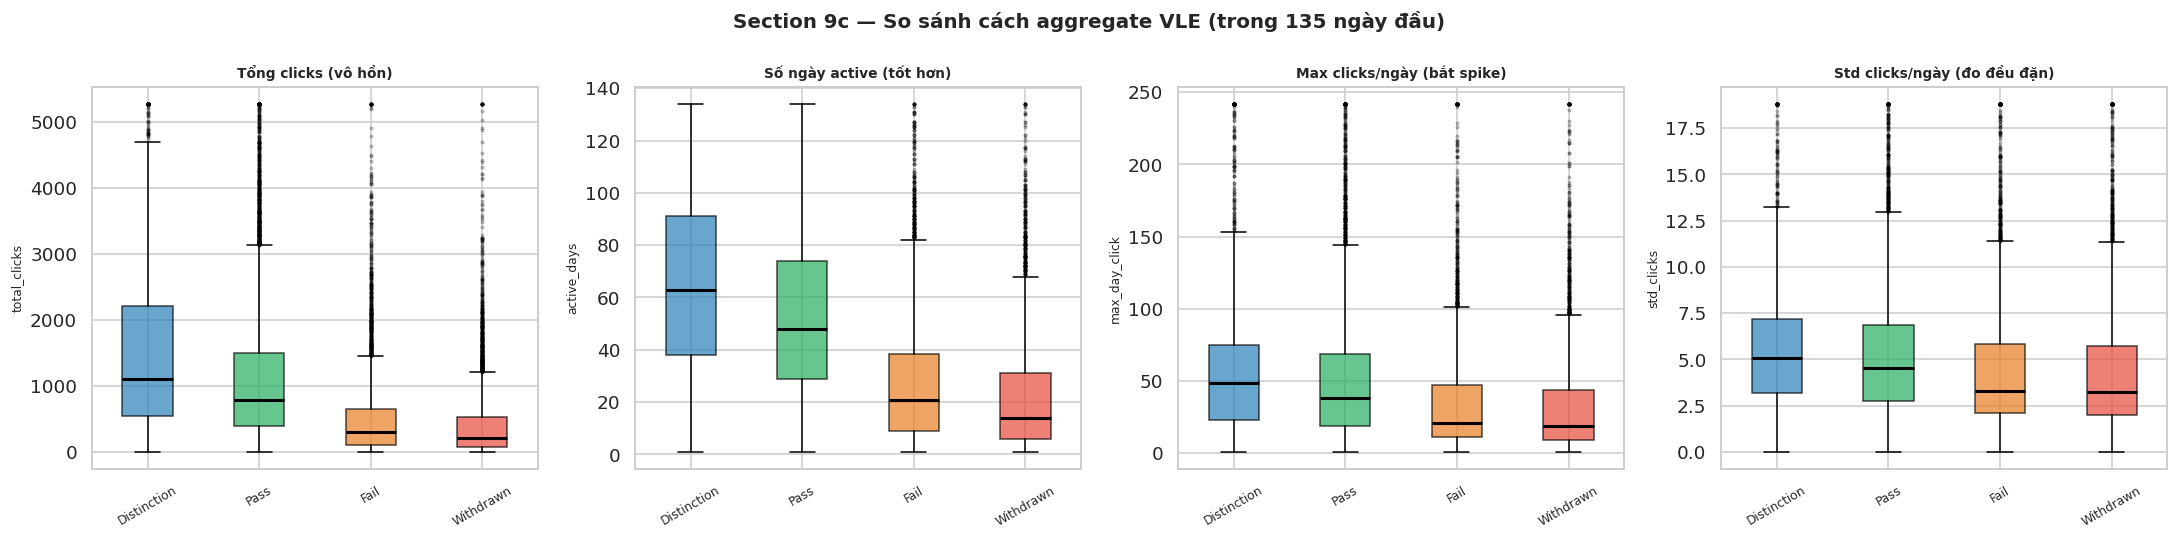

final_result
Distinction     2902
Fail            6449
Pass           11871
Withdrawn       6551
Name: n_students, dtype: int64


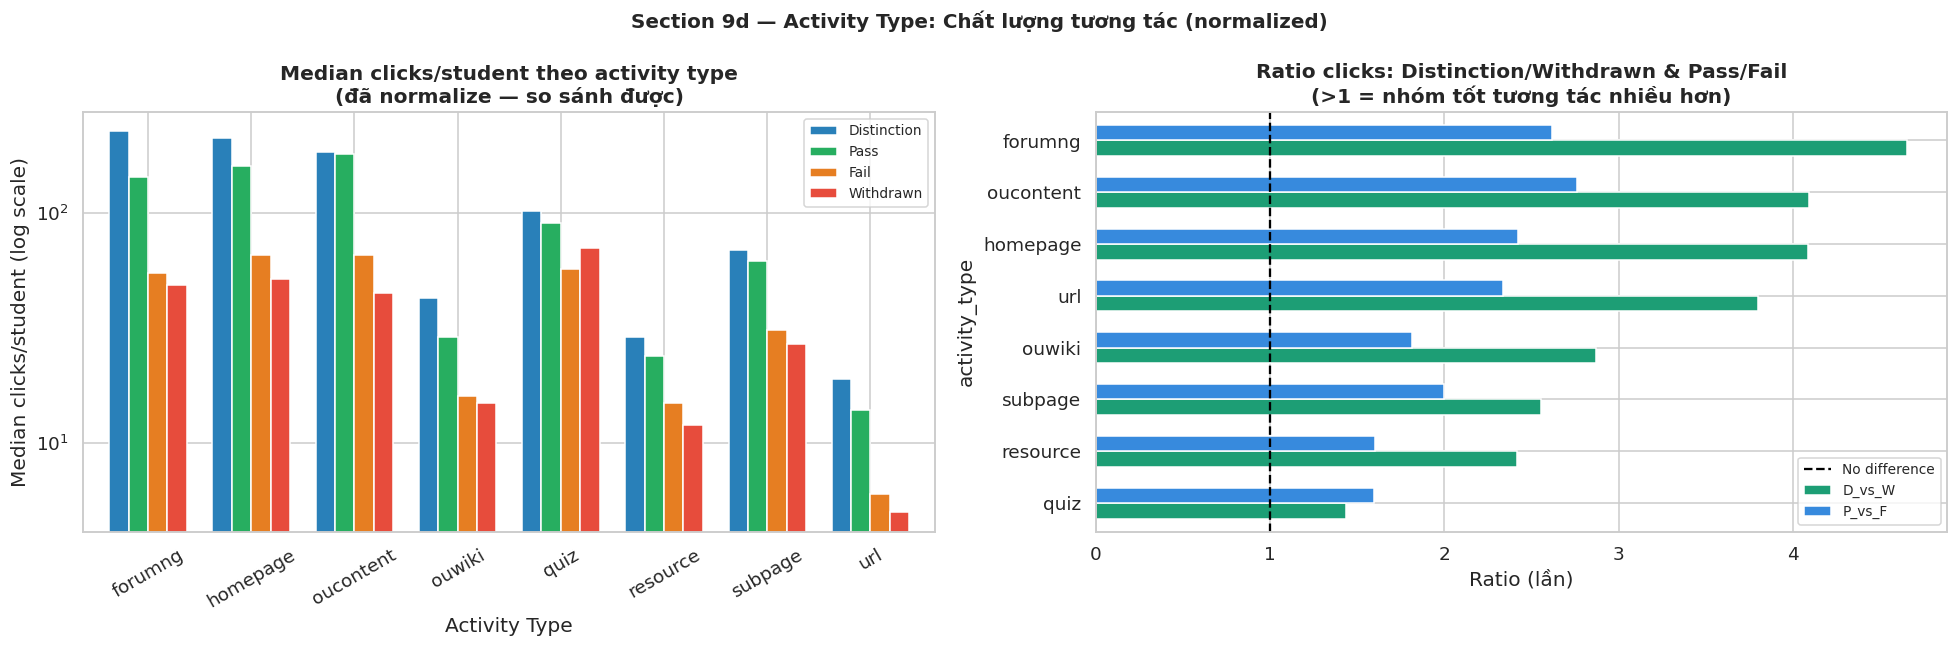


=== Ratio Distinction vs Withdrawn ===
activity_type
forumng      4.65
oucontent    4.09
homepage     4.09
url          3.80
ouwiki       2.87
subpage      2.56
resource     2.42
quiz         1.44
Name: D_vs_W, dtype: float64

=== Kết luận Section 9 ===
→ Withdrawn: KDE peak ở ngày đầu → biến mất trước cut-off
→ Pass/Distinction: activity đều đặn suốt module
→ KHÔNG dùng sum_click tổng — cần temporal features:
   active_days, std_clicks, last_active_day, clicks_per_week


In [12]:
def section9_vle_timeseries(cutoff_day=CUTOFF_DAY):
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_vle_raw = pd.read_csv(DATA_DIR / 'vle.csv')

    print('Loading studentVle.csv...')
    df_vle = pd.read_csv(DATA_DIR / 'studentVle.csv')

    vle = df_vle.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    del df_vle

    tma_dates = df_ass[df_ass['assessment_type'] == 'TMA']['date'].sort_values().unique()[:8]

    # ── Section 9a: Median daily clicks — 4 nhóm ─────────────────────────
    daily = (
        vle[vle['date'].between(0, 250)]
        .groupby(['final_result','date'])['sum_click']
        .median().reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    for res in RESULT_ORDER:
        g = daily[daily['final_result'] == res]
        axes[0].plot(g['date'], g['sum_click'],
                     label=res, color=RESULT_COLORS[res], linewidth=2)
    axes[0].axvline(cutoff_day, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off day {cutoff_day}')
    for d in tma_dates:
        if d <= 250:
            axes[0].axvline(d, color='purple', linestyle=':', alpha=0.35, linewidth=1)
    axes[0].set_title('Median daily clicks theo ngày\n(đường tím = TMA deadline)', fontweight='bold')
    axes[0].set_xlabel('Ngày')
    axes[0].set_ylabel('Median clicks/ngày')
    axes[0].legend(fontsize=9)

    # KDE phân phối theo thời gian
    from scipy.stats import gaussian_kde

    vle_cut = vle[vle['date'].between(0, 250)].copy()
    x_grid = np.linspace(0, 250, 500)

    for res in RESULT_ORDER:
      g = vle_cut[vle_cut['final_result'] == res]

      dates   = g['date'].values.astype(float)
      weights = g['sum_click'].values.astype(float)
      weights = weights / weights.sum()          # normalize weights

      kde = gaussian_kde(dates, weights=weights, bw_method=0.15)
      axes[1].plot(x_grid, kde(x_grid),
                 label=res, color=RESULT_COLORS[res], linewidth=2)

    axes[1].axvline(CUTOFF_DAY, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off day {CUTOFF_DAY}')
    axes[1].set_title('KDE — phân phối tương tác theo thời gian\n(Withdrawn peak sớm, biến mất nhanh)',
                      fontweight='bold')
    axes[1].set_xlabel('Ngày')
    axes[1].set_ylabel('Density')
    axes[1].legend(fontsize=9)

    # ── Section 9b: Individual click patterns ─────────────────────────────
    np.random.seed(RANDOM_STATE)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    sample_students = {}
    for i, res in enumerate(RESULT_ORDER[:3]):
        ids = vle[vle['final_result'] == res]['id_student'].unique()
        student_id = np.random.choice(ids)
        sample_students[res] = student_id

    # 2 students per group shown
    for row, offset in enumerate([0, 1]):
        for col, res in enumerate(['Pass', 'Fail', 'Withdrawn']):
            ax = axes[row][col]
            ids = vle[vle['final_result'] == res]['id_student'].unique()
            np.random.seed(RANDOM_STATE + offset * 10 + col)
            student_id = np.random.choice(ids)
            sv = vle[(vle['id_student'] == student_id) & (vle['date'].between(-30, 270))]
            sv = sv.groupby('date')['sum_click'].sum().reset_index()
            ax.bar(sv['date'], sv['sum_click'], width=1.0,
                   color=RESULT_COLORS[res], alpha=0.8, edgecolor='none')
            ax.axvline(cutoff_day, color='black', linestyle='--', linewidth=1.5)
            for d in tma_dates:
                if -30 <= d <= 270:
                    ax.axvline(d, color='purple', linestyle=':', alpha=0.3, linewidth=0.8)
            ax.set_title(f'{res} — Student {student_id}', fontweight='bold')
            ax.set_xlabel('Ngày')
            ax.set_ylabel('Clicks')

    plt.suptitle('Section 9b — Individual Click Pattern (đen = cut-off | tím = TMA deadline)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Section 9c: Aggregate comparison ─────────────────────────────────
    vle_before = vle[vle['date'] <= cutoff_day]
    agg = (
        vle_before.groupby(['code_module','code_presentation','id_student','final_result'])
        .agg(
            total_clicks=('sum_click', 'sum'),
            active_days=('date', 'nunique'),
            max_day_click=('sum_click', 'max'),
            std_clicks=('sum_click', 'std'),
        ).reset_index()
        .fillna(0)
    )

    metrics = {
        'total_clicks': 'Tổng clicks (vô hồn)',
        'active_days': 'Số ngày active (tốt hơn)',
        'max_day_click': 'Max clicks/ngày (bắt spike)',
        'std_clicks': 'Std clicks/ngày (đo đều đặn)',
    }

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (col, title) in zip(axes, metrics.items()):
        data_by_res = [agg[agg['final_result'] == r][col].clip(upper=agg[col].quantile(0.99))
                       for r in RESULT_ORDER]
        bp = ax.boxplot(data_by_res, labels=RESULT_ORDER, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        flierprops=dict(marker='.', alpha=0.3, markersize=3))
        for patch, color in zip(bp['boxes'], RESULT_CLIST):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_title(title, fontweight='bold', fontsize=9)
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.set_ylabel(col, fontsize=8)

    plt.suptitle(f'Section 9c — So sánh cách aggregate VLE (trong {cutoff_day} ngày đầu)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Số sinh viên mỗi nhóm
    n_students = (
        vle_before.groupby('final_result')['id_student']
        .nunique()
        .rename('n_students')
    )
    print(n_students)  # kiểm tra chênh lệch thực tế

    vle_with_type = vle_before.merge(
        df_vle_raw[['id_site','activity_type']], on='id_site', how='left'
    )

    # Mean clicks per student per activity type
    activity_agg = (
        vle_with_type.groupby(['activity_type', 'final_result', 'id_student'])['sum_click']
        .sum().reset_index()
        .groupby(['activity_type', 'final_result'])['sum_click']
        .median().reset_index()  # median để tránh outlier kéo lệch
        .rename(columns={'sum_click': 'median_clicks_per_student'})
    )

    top_activities = (
        activity_agg.groupby('activity_type')['median_clicks_per_student']
        .sum()
        .sort_values(ascending=False).head(8).index
    )
    activity_top = activity_agg[activity_agg['activity_type'].isin(top_activities)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # ── Left: median per student (main chart) ──
    activity_pivot = activity_top.pivot(
        index='activity_type', columns='final_result',
        values='median_clicks_per_student'
    ).fillna(0).reindex(columns=RESULT_ORDER)

    activity_pivot.plot(kind='bar', ax=axes[0],
                        color=RESULT_CLIST, edgecolor='white', width=0.75)
    axes[0].set_yscale('log')
    axes[0].set_title('Median clicks/student theo activity type\n(đã normalize — so sánh được)',
                      fontweight='bold')
    axes[0].set_xlabel('Activity Type')
    axes[0].set_ylabel('Median clicks/student (log scale)')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(title='', fontsize=9)

    # ── Right: ratio Distinction/Withdrawn để thấy gap thực sự ──
    ratio_pivot = activity_pivot.copy()
    ratio_pivot['D_vs_W'] = (
        ratio_pivot['Distinction'] / ratio_pivot['Withdrawn'].replace(0, np.nan)
    )
    ratio_pivot['P_vs_F'] = (
        ratio_pivot['Pass'] / ratio_pivot['Fail'].replace(0, np.nan)
    )

    ratio_pivot[['D_vs_W','P_vs_F']].sort_values('D_vs_W', ascending=True).plot(
        kind='barh', ax=axes[1], edgecolor='white', width=0.6,
        color=['#1D9E75','#378ADD']
    )
    axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='No difference')
    axes[1].set_title('Ratio clicks: Distinction/Withdrawn & Pass/Fail\n(>1 = nhóm tốt tương tác nhiều hơn)',
                      fontweight='bold')
    axes[1].set_xlabel('Ratio (lần)')
    axes[1].legend(fontsize=9)

    plt.suptitle('Section 9d — Activity Type: Chất lượng tương tác (normalized)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # In kết quả để đọc được số thực
    print('\n=== Ratio Distinction vs Withdrawn ===')
    print(ratio_pivot['D_vs_W'].sort_values(ascending=False).round(2))

    print('\n=== Kết luận Section 9 ===')
    print('→ Withdrawn: KDE peak ở ngày đầu → biến mất trước cut-off')
    print('→ Pass/Distinction: activity đều đặn suốt module')
    print('→ KHÔNG dùng sum_click tổng — cần temporal features:')
    print('   active_days, std_clicks, last_active_day, clicks_per_week')

section9_vle_timeseries()

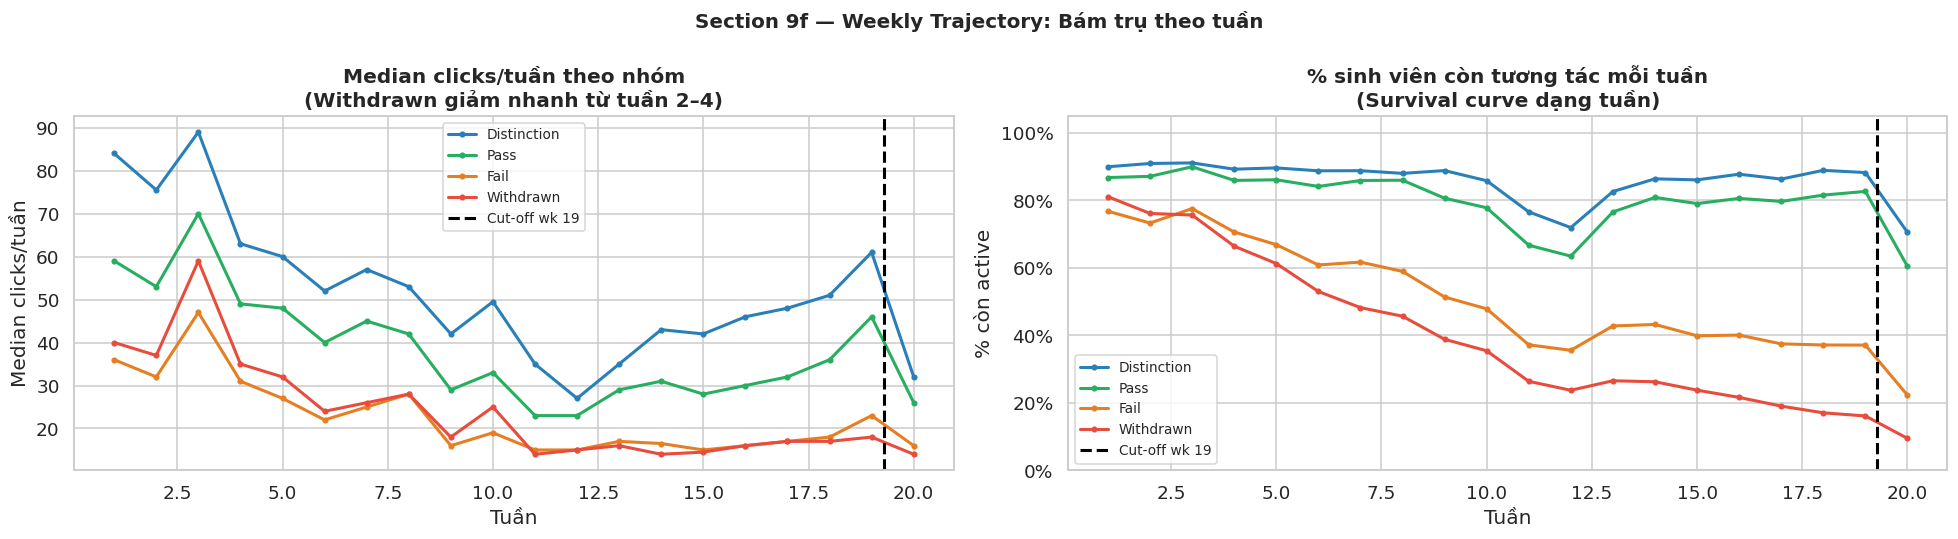

In [13]:
# ── Section 9f: Weekly trajectory (cohort-level) ──────────────────────
def section9f_weekly_trajectory(cutoff_day=CUTOFF_DAY):
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_vle  = pd.read_csv(DATA_DIR / 'studentVle.csv')

    vle = df_vle.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )

    vle_cut = vle[vle['date'].between(0, cutoff_day)].copy()
    vle_cut['week'] = (vle_cut['date'] // 7) + 1

    # Median clicks/tuần per student, rồi median across students trong nhóm
    weekly_student = (
        vle_cut.groupby(['final_result','id_student','week'])['sum_click']
        .sum().reset_index()
    )
    weekly_median = (
        weekly_student.groupby(['final_result','week'])['sum_click']
        .median().reset_index()
    )

    # % students còn active mỗi tuần (có ít nhất 1 click)
    n_students = vle_cut.groupby('final_result')['id_student'].nunique()
    weekly_active = (
        weekly_student[weekly_student['sum_click'] > 0]
        .groupby(['final_result','week'])['id_student']
        .nunique().reset_index()
    )
    weekly_active['pct_active'] = weekly_active.apply(
        lambda r: r['id_student'] / n_students[r['final_result']] * 100, axis=1
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # ── Left: Median clicks/tuần ──
    max_week = vle_cut['week'].max()
    for res in RESULT_ORDER:
        g = weekly_median[weekly_median['final_result'] == res]
        axes[0].plot(g['week'], g['sum_click'],
                     color=RESULT_COLORS[res], label=res,
                     linewidth=2, marker='o', markersize=3)

    axes[0].axvline(cutoff_day / 7, color='black', linestyle='--',
                    linewidth=2, label=f'Cut-off wk {cutoff_day//7}')
    axes[0].set_title('Median clicks/tuần theo nhóm\n(Withdrawn giảm nhanh từ tuần 2–4)',
                      fontweight='bold')
    axes[0].set_xlabel('Tuần')
    axes[0].set_ylabel('Median clicks/tuần')
    axes[0].legend(fontsize=9)

    # ── Right: % còn active mỗi tuần ──
    for res in RESULT_ORDER:
        g = weekly_active[weekly_active['final_result'] == res]
        axes[1].plot(g['week'], g['pct_active'],
                     color=RESULT_COLORS[res], label=res,
                     linewidth=2, marker='o', markersize=3)

    axes[1].axvline(cutoff_day / 7, color='black', linestyle='--',
                    linewidth=2, label=f'Cut-off wk {cutoff_day//7}')
    axes[1].set_title('% sinh viên còn tương tác mỗi tuần\n(Survival curve dạng tuần)',
                      fontweight='bold')
    axes[1].set_xlabel('Tuần')
    axes[1].set_ylabel('% còn active')
    axes[1].set_ylim(0, 105)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
    axes[1].legend(fontsize=9)

    plt.suptitle('Section 9f — Weekly Trajectory: Bám trụ theo tuần',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section9f_weekly_trajectory()

---
## Section 10 — Statistical Tests (Chi-square + Spearman)

Kiểm định toàn bộ features để justify quyết định giữ/drop.

=== Chi-square Test: Categorical vs final_result ===
          feature        chi2       p_value significance
      code_module 1443.193244 7.589955e-296     *** Mạnh
highest_education 1024.696199 9.182113e-212     *** Mạnh
         imd_band  666.935197 3.150931e-123     *** Mạnh
           region  449.715132  6.470404e-73     *** Mạnh
code_presentation  402.161774  4.736105e-81     *** Mạnh
         age_band  222.650798  2.831091e-45     *** Mạnh
       disability  138.453987  8.143196e-30     *** Mạnh
           gender   16.530150  8.827204e-04     *** Mạnh


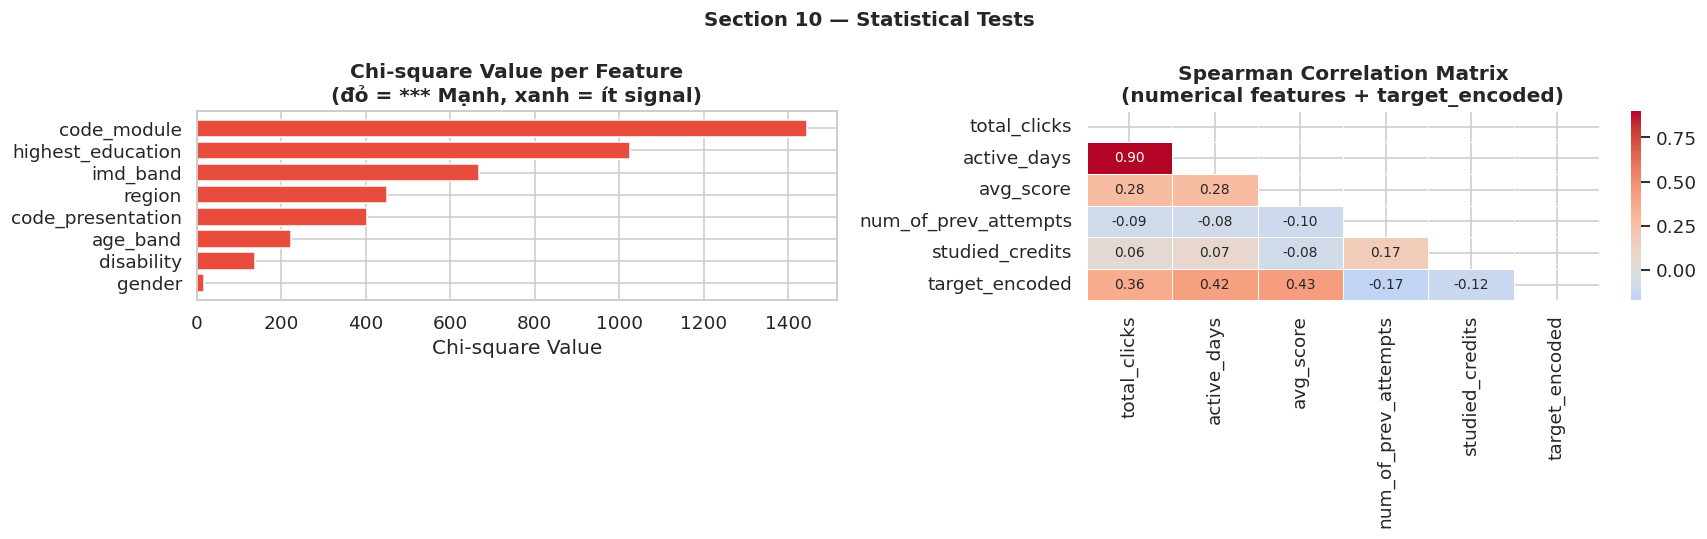

In [14]:
def section10_statistical_tests():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_sa   = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_vle  = pd.read_csv(DATA_DIR / 'studentVle.csv')

    # ── Chi-square: categorical features ─────────────────────────────────
    categorical_cols = ['gender', 'region', 'highest_education', 'imd_band',
                        'age_band', 'disability', 'code_module', 'code_presentation']

    chi_results = []
    for col in categorical_cols:
        df_clean = df_info.dropna(subset=[col])
        chi2, p, _ = chi_square_test(df_clean, col, 'final_result')
        sig = '*** Mạnh' if p < 0.001 else ('** Có ý nghĩa' if p < 0.05 else '✗ Không có ý nghĩa')
        chi_results.append({'feature': col, 'chi2': chi2, 'p_value': p, 'significance': sig})

    chi_df = pd.DataFrame(chi_results).sort_values('chi2', ascending=False)
    print('=== Chi-square Test: Categorical vs final_result ===')
    print(chi_df.to_string(index=False))

    # ── Spearman: numerical features ─────────────────────────────────────
    # VLE aggregates
    vle_merged = df_vle.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    vle_before = vle_merged[vle_merged['date'] <= CUTOFF_DAY]
    agg_vle = (
        vle_before.groupby(['id_student','final_result'])
        .agg(total_clicks=('sum_click','sum'), active_days=('date','nunique'))
        .reset_index()
    )

    # Score aggregates
    df_sa_clean = df_sa.fillna({'score': 0})
    agg_score = df_sa_clean.groupby('id_student')['score'].mean().reset_index().rename(columns={'score':'avg_score'})

    # Merge all
    num_df = agg_vle.merge(agg_score, on='id_student', how='left')
    num_df = num_df.merge(df_info[['id_student','num_of_prev_attempts','studied_credits']], on='id_student', how='left')

    target_map = {'Distinction': 3, 'Pass': 2, 'Fail': 1, 'Withdrawn': 0}
    num_df['target_encoded'] = num_df['final_result'].map(target_map)

    num_cols = ['total_clicks', 'active_days', 'avg_score', 'num_of_prev_attempts',
                'studied_credits', 'target_encoded']
    corr_data = num_df[num_cols].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Chi-square barplot
    chi_df_sorted = chi_df.sort_values('chi2', ascending=True)
    colors_chi = ['#e74c3c' if 'Mạnh' in s else '#27ae60' for s in chi_df_sorted['significance']]
    axes[0].barh(chi_df_sorted['feature'], chi_df_sorted['chi2'], color=colors_chi)
    axes[0].set_title('Chi-square Value per Feature\n(đỏ = *** Mạnh, xanh = ít signal)', fontweight='bold')
    axes[0].set_xlabel('Chi-square Value')

    # Spearman heatmap
    corr_matrix = corr_data.corr(method='spearman')
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=axes[1], mask=mask,
                annot_kws={'size': 9})
    axes[1].set_title('Spearman Correlation Matrix\n(numerical features + target_encoded)', fontweight='bold')

    plt.suptitle('Section 10 — Statistical Tests', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section10_statistical_tests()

Saved: section5_distinction_features.png


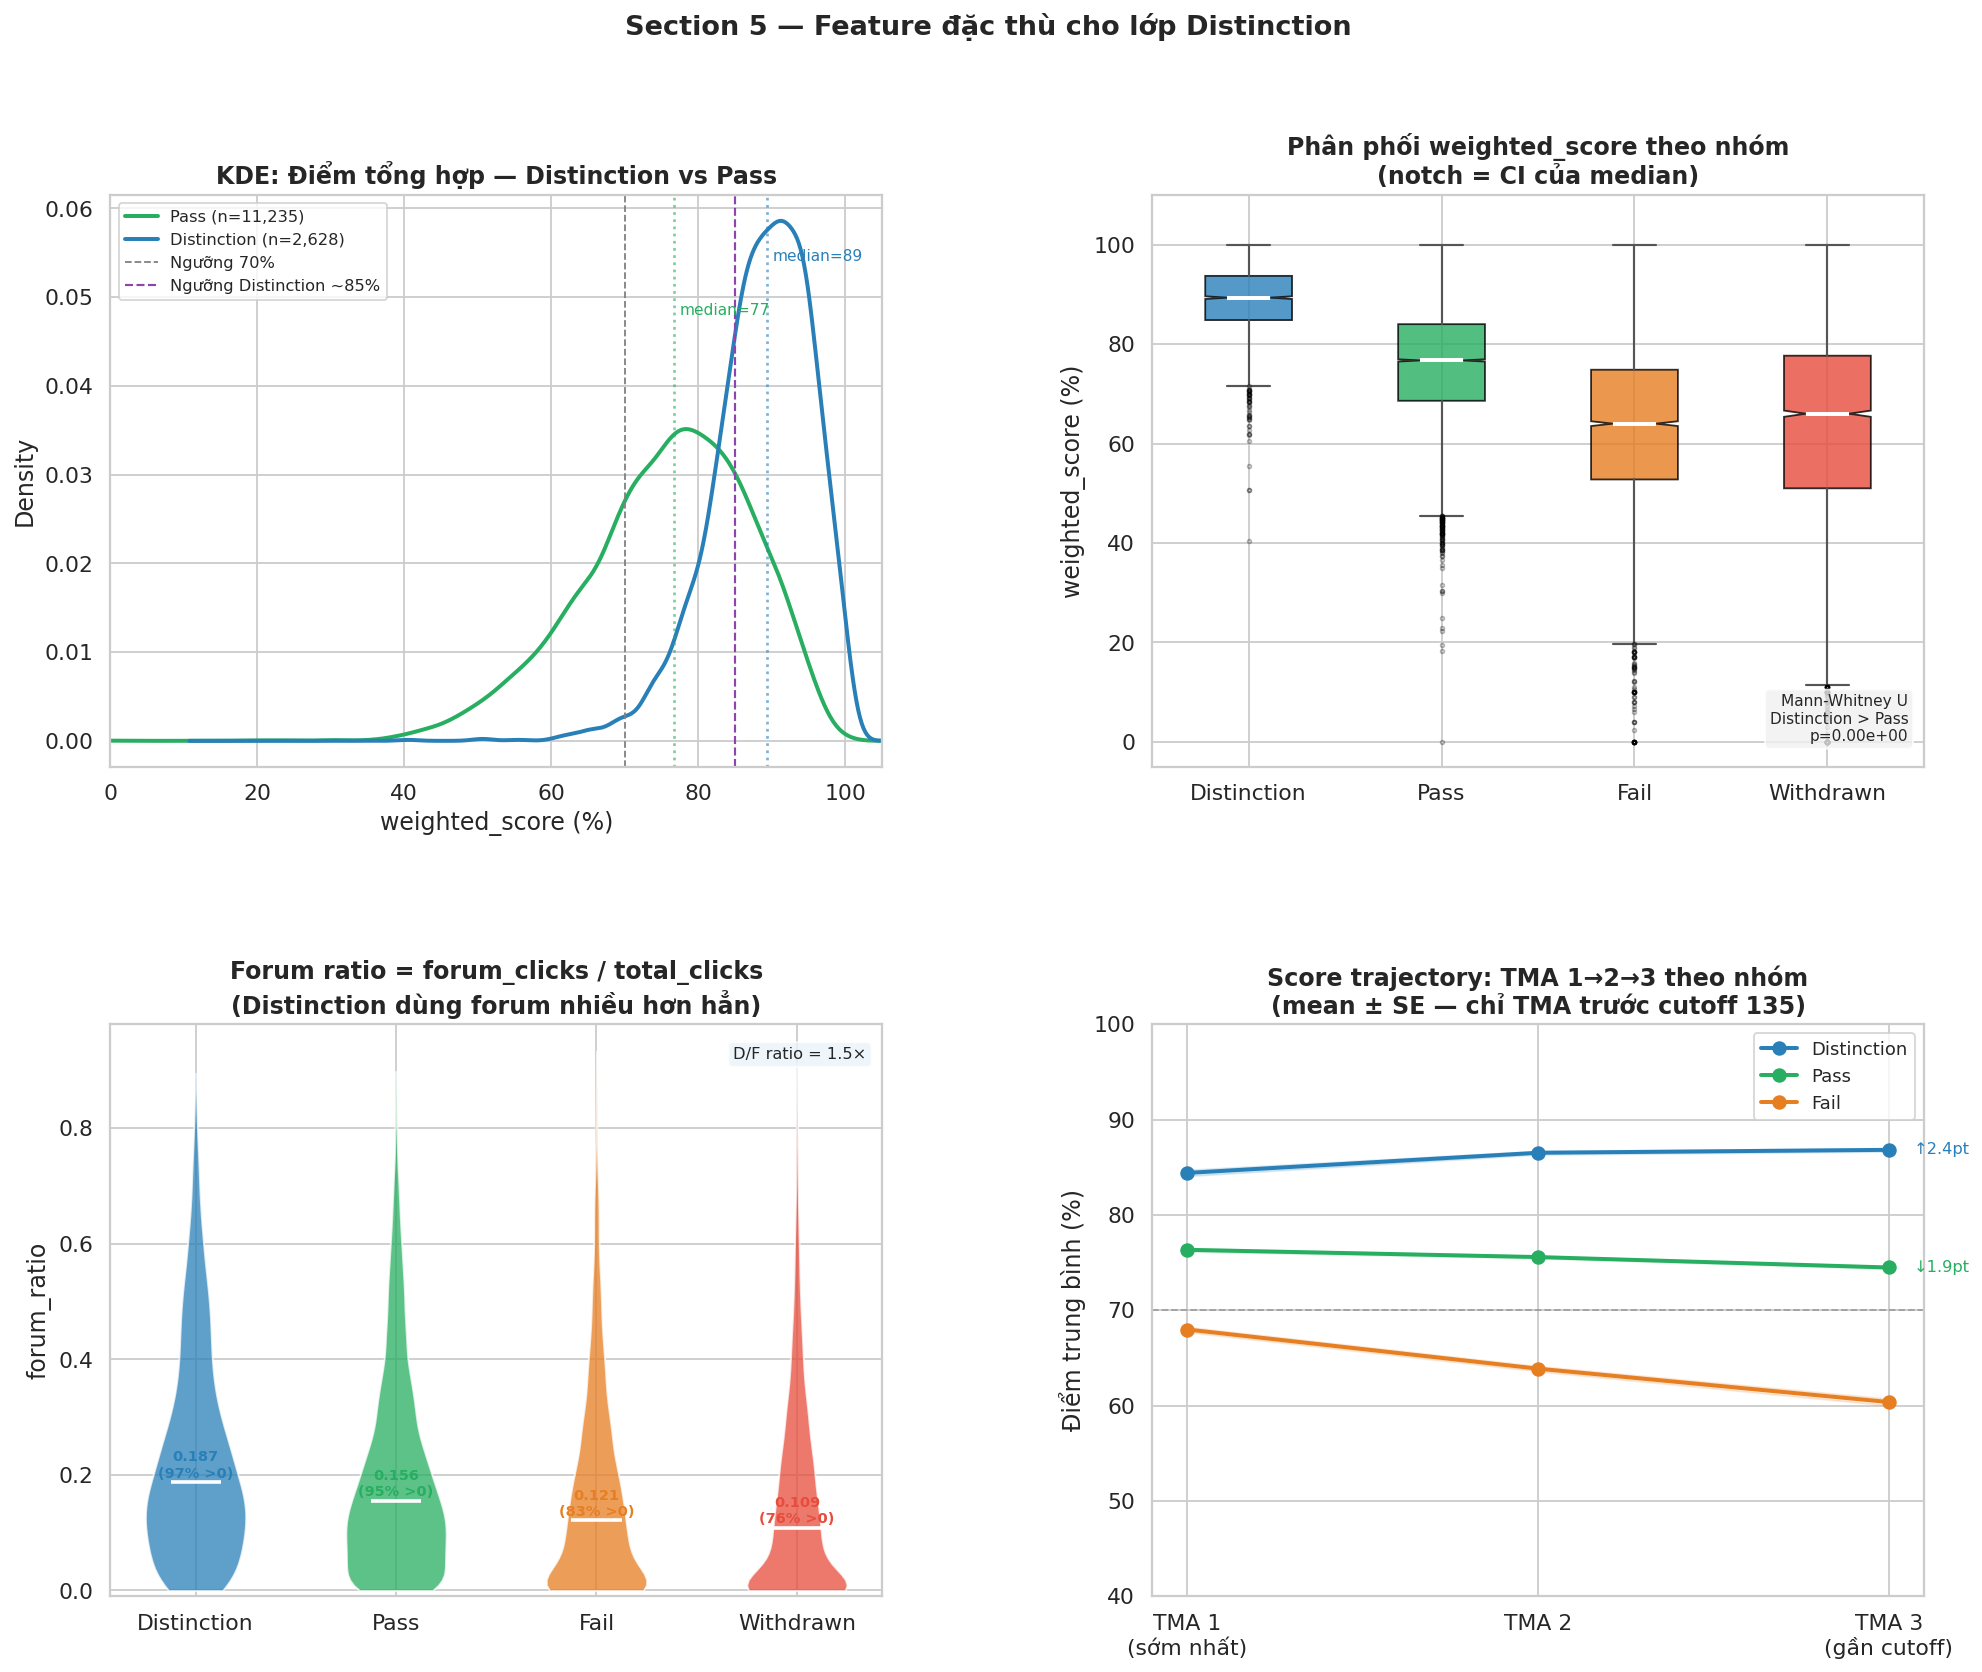

In [17]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 130
mpl.rcParams['font.family'] = 'DejaVu Sans'

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR   = Path("/content/drive/MyDrive/Dataset/")  # Updated to the correct data directory
CUTOFF_DAY = 135

RESULT_ORDER  = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
COLORS = {
    'Distinction': '#2980b9',
    'Pass':        '#27ae60',
    'Fail':        '#e67e22',
    'Withdrawn':   '#e74c3c',
}

# ─────────────────────────────────────────────────────────────────────────────

def section5_distinction_features():

    # ── Load data ─────────────────────────────────────────────────────────────
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_sa   = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_vle  = pd.read_csv(DATA_DIR / 'studentVle.csv')
    df_reg  = pd.read_csv(DATA_DIR / 'studentRegistration.csv')

    # ── Prep: merge assessment scores ────────────────────────────────────────
    df_merged = df_sa.merge(df_ass[['id_assessment', 'assessment_type', 'weight', 'date', 'code_module', 'code_presentation']],
                            on='id_assessment', how='left')
    df_merged = df_merged.merge(
        df_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
        on=['id_student', 'code_module', 'code_presentation'], how='left'
    )
    df_merged = df_merged[df_merged['assessment_type'].isin(['TMA', 'CMA'])]
    df_merged = df_merged[df_merged['date'] <= CUTOFF_DAY]
    df_merged['score'] = pd.to_numeric(df_merged['score'], errors='coerce')

    # Weighted score per student
    def weighted_mean(g):
        w = g['weight'].fillna(1)
        s = g['score'].fillna(0)
        denom = w.sum()
        return (s * w).sum() / denom if denom > 0 else np.nan

    score_per_student = (
        df_merged.groupby(['id_student', 'code_module', 'code_presentation'])
        .apply(weighted_mean)
        .reset_index(name='weighted_score')
        .merge(df_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
               on=['id_student', 'code_module', 'code_presentation'], how='left')
    )
    score_per_student = score_per_student.dropna(subset=['weighted_score', 'final_result'])

    # ── Prep: forum clicks per student ───────────────────────────────────────
    df_vle_info = df_vle.merge(
        pd.read_csv(DATA_DIR / 'vle.csv')[['id_site', 'activity_type']],
        on='id_site', how='left'
    )
    df_vle_cut = df_vle_info[df_vle_info['date'] <= CUTOFF_DAY]

    total_clicks = (
        df_vle_cut.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
        .sum().reset_index(name='total_clicks')
    )
    forum_clicks = (
        df_vle_cut[df_vle_cut['activity_type'] == 'forumng']
        .groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
        .sum().reset_index(name='forum_clicks')
    )
    vle_merged = total_clicks.merge(forum_clicks, on=['id_student', 'code_module', 'code_presentation'], how='left')
    vle_merged['forum_clicks'] = vle_merged['forum_clicks'].fillna(0)
    vle_merged['forum_ratio'] = vle_merged['forum_clicks'] / (vle_merged['total_clicks'] + 1)
    vle_merged = vle_merged.merge(
        df_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
        on=['id_student', 'code_module', 'code_presentation'], how='left'
    )

    # ── Prep: score trajectory ────────────────────────────────────────────────
    # Lấy TMA-only, sắp xếp theo date, lấy TMA thứ 1-2-3
    tma = df_merged[df_merged['assessment_type'] == 'TMA'].copy()
    tma['score'] = pd.to_numeric(tma['score'], errors='coerce')
    tma = tma.dropna(subset=['score', 'date'])

    # Rank TMA theo date trong từng (student, module, presentation)
    tma['tma_rank'] = (
        tma.sort_values('date')
           .groupby(['id_student', 'code_module', 'code_presentation'])
           .cumcount() + 1
    )
    tma_top3 = tma[tma['tma_rank'] <= 3]

    traj = (
        tma_top3.groupby(['final_result', 'tma_rank'])['score']
        .agg(['mean', 'sem'])
        .reset_index()
    )

    # ── Figure layout ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    ax1a = fig.add_subplot(gs[0, 0])   # KDE Distinction vs Pass
    ax1b = fig.add_subplot(gs[0, 1])   # Boxplot all 4 classes
    ax2  = fig.add_subplot(gs[1, 0])   # Forum ratio violin
    ax3  = fig.add_subplot(gs[1, 1])   # Score trajectory

    fig.suptitle('Section 5 — Feature đặc thù cho lớp Distinction',
                 fontsize=15, fontweight='bold', y=0.98)

    # ── Fig 1a: KDE weighted_score — Distinction vs Pass ─────────────────────
    for res in ['Pass', 'Distinction']:
        vals = score_per_student[score_per_student['final_result'] == res]['weighted_score'].dropna()
        vals.plot.kde(ax=ax1a, label=f'{res} (n={len(vals):,})',
                      color=COLORS[res], linewidth=2.2)

    ax1a.axvline(x=70, color='grey', linestyle='--', linewidth=1, label='Ngưỡng 70%')
    ax1a.axvline(x=85, color='#8e44ad', linestyle='--', linewidth=1.2, label='Ngưỡng Distinction ~85%')
    ax1a.set_title('KDE: Điểm tổng hợp — Distinction vs Pass', fontweight='bold')
    ax1a.set_xlabel('weighted_score (%)')
    ax1a.set_ylabel('Density')
    ax1a.legend(fontsize=9)
    ax1a.set_xlim(0, 105)

    # Annotate median lines
    for res in ['Pass', 'Distinction']:
        med = score_per_student[score_per_student['final_result'] == res]['weighted_score'].median()
        ax1a.axvline(med, color=COLORS[res], linestyle=':', alpha=0.6, linewidth=1.5)
        ax1a.text(med + 0.8, ax1a.get_ylim()[1] * 0.88 if res == 'Distinction' else ax1a.get_ylim()[1] * 0.78,
                  f'median={med:.0f}', color=COLORS[res], fontsize=8.5)

    # ── Fig 1b: Boxplot weighted_score — 4 classes ───────────────────────────
    data_box = [
        score_per_student[score_per_student['final_result'] == r]['weighted_score'].dropna().values
        for r in RESULT_ORDER
    ]
    bp = ax1b.boxplot(data_box, patch_artist=True, notch=True,
                      medianprops=dict(color='white', linewidth=2.2),
                      flierprops=dict(marker='o', markersize=2, alpha=0.3))

    for patch, res in zip(bp['boxes'], RESULT_ORDER):
        patch.set_facecolor(COLORS[res])
        patch.set_alpha(0.8)
    for whisker in bp['whiskers']:
        whisker.set(color='#555', linewidth=1.2)
    for cap in bp['caps']:
        cap.set(color='#555', linewidth=1.2)

    ax1b.set_xticks(range(1, 5))
    ax1b.set_xticklabels(RESULT_ORDER)
    ax1b.set_title('Phân phối weighted_score theo nhóm\n(notch = CI của median)', fontweight='bold')
    ax1b.set_ylabel('weighted_score (%)')
    ax1b.set_ylim(-5, 110)

    # U-test Distinction vs Pass annotation
    d_scores = score_per_student[score_per_student['final_result'] == 'Distinction']['weighted_score'].dropna()
    p_scores = score_per_student[score_per_student['final_result'] == 'Pass']['weighted_score'].dropna()
    _, p_val = mannwhitneyu(d_scores, p_scores, alternative='greater')
    ax1b.text(0.98, 0.04, f'Mann-Whitney U\nDistinction > Pass\np={p_val:.2e}',
              transform=ax1b.transAxes, ha='right', va='bottom', fontsize=8.5,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))

    # ── Fig 2: Forum ratio violin ─────────────────────────────────────────────
    plot_data  = [vle_merged[vle_merged['final_result'] == r]['forum_ratio'].dropna().values
                  for r in RESULT_ORDER]
    parts = ax2.violinplot(plot_data, positions=range(1, 5),
                           showmedians=True, showextrema=False)

    for i, (pc, res) in enumerate(zip(parts['bodies'], RESULT_ORDER)):
        pc.set_facecolor(COLORS[res])
        pc.set_alpha(0.75)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)

    # Overlay medians as text
    for i, res in enumerate(RESULT_ORDER):
        vals = vle_merged[vle_merged['final_result'] == res]['forum_ratio'].dropna()
        med = vals.median()
        pct_nonzero = (vals > 0).mean() * 100
        ax2.text(i + 1, med + 0.003, f'{med:.3f}\n({pct_nonzero:.0f}% >0)',
                 ha='center', va='bottom', fontsize=8, color=COLORS[res], fontweight='bold')

    ax2.set_xticks(range(1, 5))
    ax2.set_xticklabels(RESULT_ORDER)
    ax2.set_title('Forum ratio = forum_clicks / total_clicks\n(Distinction dùng forum nhiều hơn hẳn)',
                  fontweight='bold')
    ax2.set_ylabel('forum_ratio')
    ax2.set_ylim(-0.01, ax2.get_ylim()[1])

    # Ratio annotation
    d_med = vle_merged[vle_merged['final_result'] == 'Distinction']['forum_ratio'].median()
    f_med = vle_merged[vle_merged['final_result'] == 'Fail']['forum_ratio'].median()
    if f_med > 0:
        ratio_txt = f'D/F ratio = {d_med/f_med:.1f}\u00d7'
    else:
        ratio_txt = 'Fail median \u2248 0'
    ax2.text(0.98, 0.96, ratio_txt, transform=ax2.transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#eaf4fb', alpha=0.8))

    # ── Fig 3: Score trajectory TMA 1\u21922\u21923 ────────────────────────────────────
    for res in ['Distinction', 'Pass', 'Fail']:
        sub = traj[traj['final_result'] == res].sort_values('tma_rank')
        if sub.empty:
            continue
        ax3.plot(sub['tma_rank'], sub['mean'],
                 marker='o', color=COLORS[res], linewidth=2.2,
                 markersize=7, label=res, zorder=3)
        ax3.fill_between(sub['tma_rank'],
                         sub['mean'] - sub['sem'],
                         sub['mean'] + sub['sem'],
                         alpha=0.15, color=COLORS[res])

    ax3.set_xticks([1, 2, 3])
    ax3.set_xticklabels(['TMA 1\n(sớm nhất)', 'TMA 2', 'TMA 3\n(gần cutoff)'])
    ax3.set_title('Score trajectory: TMA 1\u21922\u21923 theo nhóm\n(mean \u00b1 SE — chỉ TMA trước cutoff 135)',
                  fontweight='bold')
    ax3.set_ylabel('Điểm trung bình (%)')
    ax3.set_ylim(40, 100)
    ax3.legend(fontsize=10)
    ax3.axhline(y=70, color='grey', linestyle='--', linewidth=1, alpha=0.6, label='Pass threshold')

    # Annotate slope direction
    for res in ['Distinction', 'Pass']:
        sub = traj[traj['final_result'] == res].sort_values('tma_rank')
        if len(sub) >= 2:
            delta = sub['mean'].iloc[-1] - sub['mean'].iloc[0]
            sign = '\u2191' if delta > 0 else '\u2193'
            ax3.text(3.07, sub['mean'].iloc[-1],
                     f'{sign}{abs(delta):.1f}pt', color=COLORS[res],
                     fontsize=9, va='center')

    plt.savefig('section5_distinction_features.png', dpi=130, bbox_inches='tight')
    print("Saved: section5_distinction_features.png")
    plt.show()


if __name__ == '__main__':
    section5_distinction_features()

Saved: section6_fail_vs_withdrawn.png


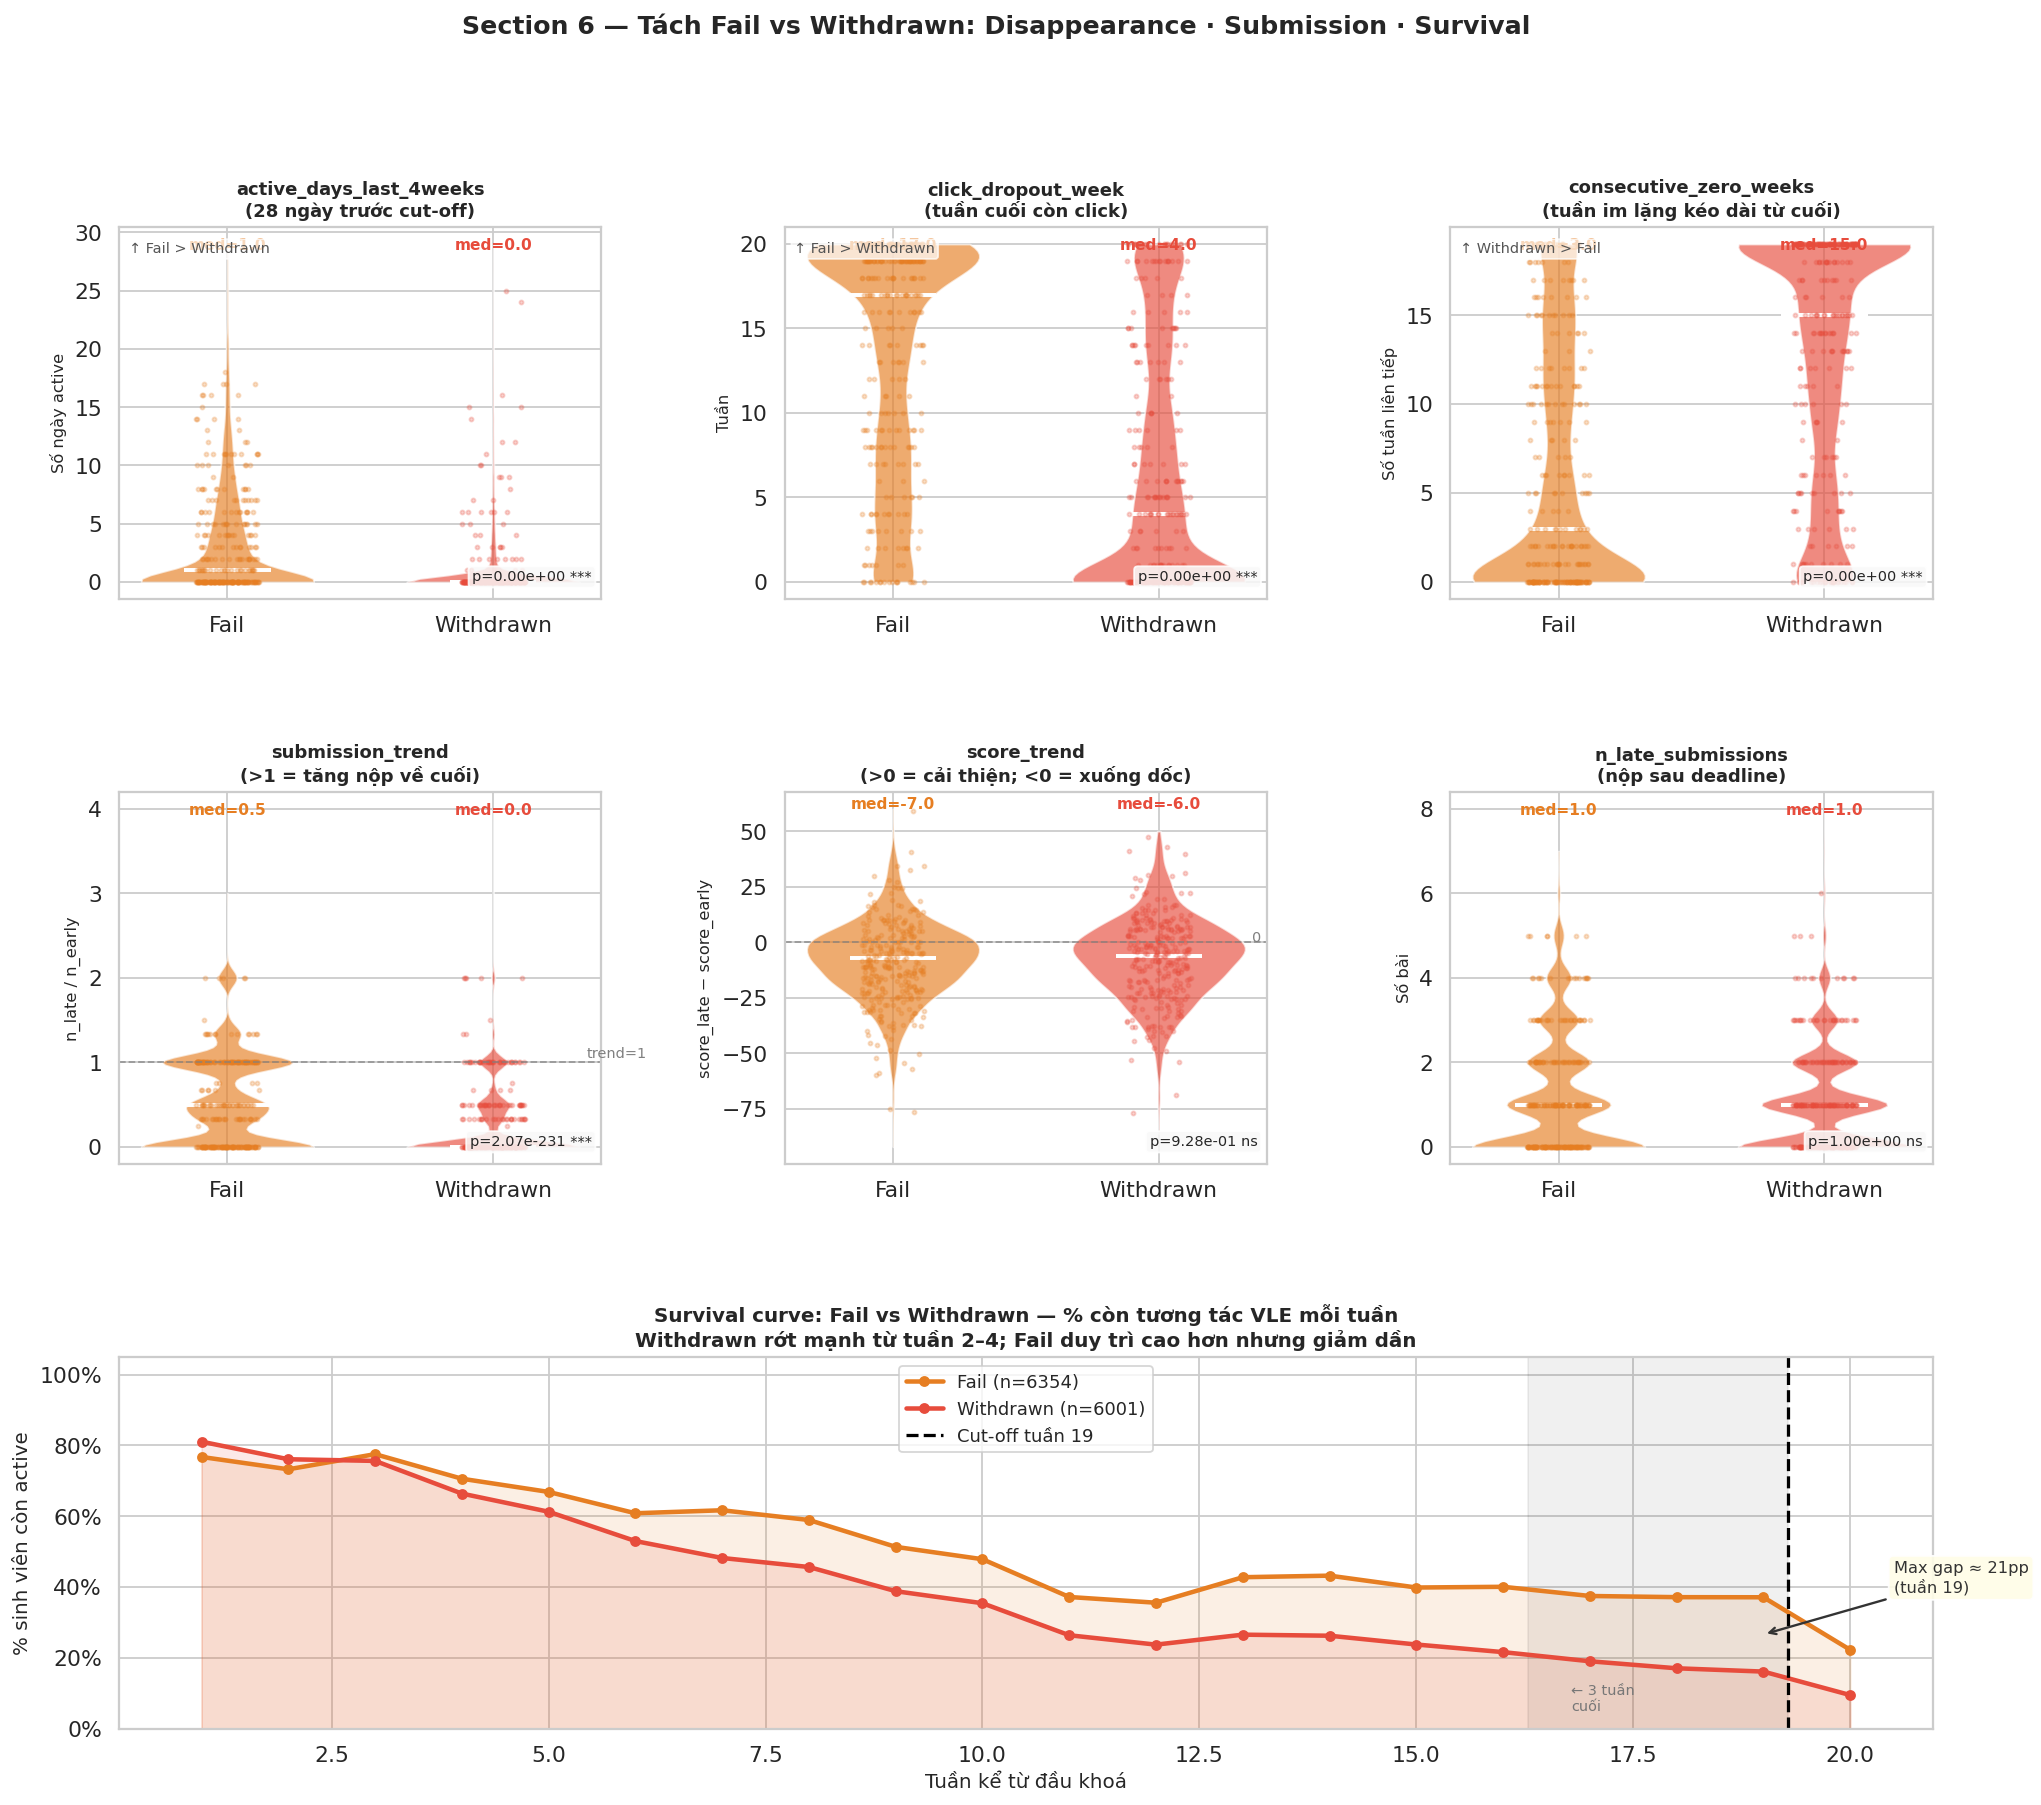

In [20]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 130
mpl.rcParams['font.family'] = 'DejaVu Sans'

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR   = Path("/content/drive/MyDrive/Dataset/")   # ← đổi thành path chứa CSV
CUTOFF_DAY = 135
MID_DAY    = CUTOFF_DAY // 2   # = 67

COLORS = {
    'Distinction': '#2980b9',
    'Pass':        '#27ae60',
    'Fail':        '#e67e22',
    'Withdrawn':   '#e74c3c',
}
FW_COLORS = ['#e67e22', '#e74c3c']   # Fail, Withdrawn

# ─────────────────────────────────────────────────────────────────────────────

def _mwu_label(a, b, alt='two-sided'):
    """Mann-Whitney U — trả về chuỗi annotation p-value."""
    _, p = mannwhitneyu(a, b, alternative=alt)
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    return f'p={p:.2e} {stars}'


def section6_fail_vs_withdrawn():

    # ── Load ──────────────────────────────────────────────────────────────────
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_sa   = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_vle  = pd.read_csv(DATA_DIR / 'studentVle.csv')

    # Chỉ giữ Fail và Withdrawn
    df_fw   = df_info[df_info['final_result'].isin(['Fail', 'Withdrawn'])].copy()
    keys    = ['id_student', 'code_module', 'code_presentation']

    # ── Cụm 1: Disappearance signals ─────────────────────────────────────────
    vle_cut = df_vle[df_vle['date'].between(0, CUTOFF_DAY)].merge(
        df_fw[keys + ['final_result']], on=keys, how='inner'
    )

    # active_days_last_4weeks
    last4 = vle_cut[vle_cut['date'] >= (CUTOFF_DAY - 28)]
    adf_last4 = (
        last4.groupby(keys + ['final_result'])['date']
        .nunique().reset_index(name='active_days_last4w')
    )
    # Pad zeros cho students không xuất hiện trong 28 ngày cuối
    adf_last4 = df_fw[keys + ['final_result']].merge(adf_last4, on=keys + ['final_result'], how='left')
    adf_last4['active_days_last4w'] = adf_last4['active_days_last4w'].fillna(0)

    # click_dropout_week (tuần cuối cùng còn click)
    vle_cut['week'] = vle_cut['date'] // 7 + 1
    dropout = (
        vle_cut.groupby(keys + ['final_result'])['week']
        .max().reset_index(name='click_dropout_week')
    )
    dropout = df_fw[keys + ['final_result']].merge(dropout, on=keys + ['final_result'], how='left')
    dropout['click_dropout_week'] = dropout['click_dropout_week'].fillna(0)

    # consecutive_zero_weeks (đếm ngược từ cut-off tuần W=19)
    MAX_WEEK = CUTOFF_DAY // 7  # = 19
    active_weeks = (
        vle_cut.groupby(keys + ['final_result', 'week'])
        .size().reset_index()[keys + ['final_result', 'week']]
    )
    def _consec_zeros(grp):
        weeks = set(grp['week'].values)
        k = 0
        for w in range(MAX_WEEK, 0, -1):
            if w not in weeks:
                k += 1
            else:
                break
        return k

    czw = (
        active_weeks.groupby(keys + ['final_result'])
        .apply(_consec_zeros).reset_index(name='consec_zero_weeks')
    )
    czw = df_fw[keys + ['final_result']].merge(czw, on=keys + ['final_result'], how='left')
    czw['consec_zero_weeks'] = czw['consec_zero_weeks'].fillna(MAX_WEEK)

    # ── Cụm 2: Submission signals ────────────────────────────────────────────
    sa = df_sa.merge(
        df_ass[['id_assessment', 'date', 'assessment_type', 'code_module', 'code_presentation']],
        on='id_assessment', how='left'
    ).merge(df_fw[keys + ['final_result']], on=['id_student', 'code_module', 'code_presentation'], how='inner')
    sa = sa[sa['assessment_type'].isin(['TMA', 'CMA'])]
    sa = sa[sa['date'] <= CUTOFF_DAY]
    sa['score'] = pd.to_numeric(sa['score'], errors='coerce')

    def _sub_features(grp):
        early = grp[grp['date'] <= MID_DAY]
        late  = grp[grp['date'] >  MID_DAY]
        n_early = len(early)
        n_late  = len(late)
        sub_trend = (n_late / n_early) if n_early > 0 else 0

        score_early = early['score'].mean() if n_early > 0 else np.nan
        score_late  = late['score'].mean()  if n_late  > 0 else np.nan
        score_trend = (score_late - score_early) if (not np.isnan(score_early) and not np.isnan(score_late)) else np.nan

        n_late_sub = (grp['date_submitted'] > grp['date']).sum() if 'date_submitted' in grp.columns else np.nan
        return pd.Series({
            'submission_trend': sub_trend,
            'score_trend':      score_trend,
            'n_late_sub':       n_late_sub,
        })

    sub_feats = (
        sa.groupby(keys + ['final_result'])
        .apply(_sub_features)
        .reset_index()
    )

    # ── Cụm 3: Survival curve zoom ───────────────────────────────────────────
    n_students = vle_cut.groupby('final_result')['id_student'].nunique()
    weekly_active = (
        vle_cut[vle_cut['sum_click'] > 0]
        .groupby(['final_result', 'week'])['id_student']
        .nunique().reset_index()
    )
    weekly_active['pct_active'] = weekly_active.apply(
        lambda r: r['id_student'] / n_students[r['final_result']] * 100, axis=1
    )

    # ── Figure ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 15))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

    ax_d1  = fig.add_subplot(gs[0, 0])   # active_days_last4w
    ax_d2  = fig.add_subplot(gs[0, 1])   # click_dropout_week
    ax_d3  = fig.add_subplot(gs[0, 2])   # consec_zero_weeks
    ax_s1  = fig.add_subplot(gs[1, 0])   # submission_trend
    ax_s2  = fig.add_subplot(gs[1, 1])   # score_trend
    ax_s3  = fig.add_subplot(gs[1, 2])   # n_late_sub
    ax_sur = fig.add_subplot(gs[2, :])   # survival curve (full width)

    fig.suptitle('Section 6 — Tách Fail vs Withdrawn: Disappearance · Submission · Survival',
                 fontsize=14, fontweight='bold', y=0.99)

    def _violin_pair(ax, data_fail, data_with, ylabel, title, better='lower'):
        """Violin plot + stripplot + MWU annotation cho cặp Fail / Withdrawn."""
        data_fail  = pd.Series(data_fail).dropna()
        data_with  = pd.Series(data_with).dropna()

        parts = ax.violinplot([data_fail, data_with], positions=[1, 2],
                               showmedians=True, showextrema=False,
                               widths=0.65)
        for pc, c in zip(parts['bodies'], FW_COLORS):
            pc.set_facecolor(c); pc.set_alpha(0.65)
        parts['cmedians'].set_color('white')
        parts['cmedians'].set_linewidth(2.2)

        # Jitter strip
        rng = np.random.default_rng(42)
        for i, (vals, c) in enumerate([(data_fail, FW_COLORS[0]), (data_with, FW_COLORS[1])], 1):
            sample = vals.sample(min(300, len(vals)), random_state=42)
            jitter = rng.uniform(-0.12, 0.12, len(sample))
            ax.scatter(i + jitter, sample, s=5, alpha=0.25, color=c, zorder=2)

        # Median labels
        for i, (vals, label) in enumerate([(data_fail, 'Fail'), (data_with, 'Withdrawn')], 1):
            med = vals.median()
            ax.text(i, ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] > 0 else med * 1.05,
                    f'med={med:.1f}', ha='center', va='top',
                    color=COLORS[label], fontsize=8.5, fontweight='bold')

        # MWU
        alt = 'less' if better == 'lower' else 'greater'
        lbl = _mwu_label(data_fail, data_with, alt=alt)
        ax.text(0.98, 0.04, lbl, transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.25', fc='#f9f9f9', alpha=0.85))

        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Fail', 'Withdrawn'])
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title, fontweight='bold', fontsize=10)

    # ── Row 1: Disappearance ──────────────────────────────────────────────────
    f_last4 = adf_last4[adf_last4['final_result'] == 'Fail']['active_days_last4w']
    w_last4 = adf_last4[adf_last4['final_result'] == 'Withdrawn']['active_days_last4w']
    _violin_pair(ax_d1, f_last4, w_last4,
                 'Số ngày active',
                 'active_days_last_4weeks\n(28 ngày trước cut-off)',
                 better='higher')

    f_drop = dropout[dropout['final_result'] == 'Fail']['click_dropout_week']
    w_drop = dropout[dropout['final_result'] == 'Withdrawn']['click_dropout_week']
    _violin_pair(ax_d2, f_drop, w_drop,
                 'Tuần',
                 'click_dropout_week\n(tuần cuối còn click)',
                 better='higher')

    f_czw = czw[czw['final_result'] == 'Fail']['consec_zero_weeks']
    w_czw = czw[czw['final_result'] == 'Withdrawn']['consec_zero_weeks']
    _violin_pair(ax_d3, f_czw, w_czw,
                 'Số tuần liên tiếp',
                 'consecutive_zero_weeks\n(tuần im lặng kéo dài từ cuối)',
                 better='lower')

    # shared note trên row 1
    for ax, note in [(ax_d1, 'Fail > Withdrawn'), (ax_d2, 'Fail > Withdrawn'), (ax_d3, 'Withdrawn > Fail')]:
        ax.text(0.02, 0.96, f'\u2191 {note}', transform=ax.transAxes,
                ha='left', va='top', fontsize=8, color='#555',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    # ── Row 2: Submission signals ─────────────────────────────────────────────
    f_st = sub_feats[sub_feats['final_result'] == 'Fail']['submission_trend']
    w_st = sub_feats[sub_feats['final_result'] == 'Withdrawn']['submission_trend']
    _violin_pair(ax_s1, f_st.clip(0, 5), w_st.clip(0, 5),
                 'n_late / n_early',
                 'submission_trend\n(>1 = tăng nộp về cuối)',
                 better='higher')
    ax_s1.axhline(1.0, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax_s1.text(2.35, 1.05, 'trend=1', color='grey', fontsize=8)

    f_sc = sub_feats[sub_feats['final_result'] == 'Fail']['score_trend']
    w_sc = sub_feats[sub_feats['final_result'] == 'Withdrawn']['score_trend']
    _violin_pair(ax_s2, f_sc, w_sc,
                 'score_late \u2212 score_early',
                 'score_trend\n(>0 = cải thiện; <0 = xuống dốc)',
                 better='higher')
    ax_s2.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax_s2.text(2.35, 0.5, '0', color='grey', fontsize=8)

    if sub_feats['n_late_sub'].notna().any():
        f_nl = sub_feats[sub_feats['final_result'] == 'Fail']['n_late_sub']
        w_nl = sub_feats[sub_feats['final_result'] == 'Withdrawn']['n_late_sub']
        _violin_pair(ax_s3, f_nl, w_nl,
                     'Số bài',
                     'n_late_submissions\n(nộp sau deadline)',
                     better='lower')
    else:
        ax_s3.text(0.5, 0.5, 'date_submitted\nkhông có trong dataset\nnày',
                   ha='center', va='center', transform=ax_s3.transAxes,
                   fontsize=10, color='grey')
        ax_s3.set_title('n_late_submissions', fontweight='bold', fontsize=10)

    # ── Row 3: Survival curve zoom ────────────────────────────────────────────
    for res in ['Fail', 'Withdrawn']:
        g = weekly_active[weekly_active['final_result'] == res].sort_values('week')
        ax_sur.plot(g['week'], g['pct_active'],
                    color=COLORS[res], linewidth=2.5, marker='o', markersize=5,
                    label=f'{res} (n={n_students.get(res, "?")})')
        # Fill under curve
        ax_sur.fill_between(g['week'], g['pct_active'], alpha=0.12, color=COLORS[res])

    ax_sur.axvline(CUTOFF_DAY / 7, color='black', linestyle='--', linewidth=1.8,
                   label=f'Cut-off tuần {CUTOFF_DAY//7}')

    # Annotate divergence point
    fw_merge = weekly_active[weekly_active['final_result'].isin(['Fail', 'Withdrawn'])]
    pivot = fw_merge.pivot(index='week', columns='final_result', values='pct_active').dropna()
    if not pivot.empty and 'Fail' in pivot and 'Withdrawn' in pivot:
        gap = (pivot['Fail'] - pivot['Withdrawn']).abs()
        diverge_week = gap.idxmax()
        diverge_val  = (pivot.loc[diverge_week, 'Fail'] + pivot.loc[diverge_week, 'Withdrawn']) / 2
        ax_sur.annotate(
            f'Max gap \u2248 {gap.max():.0f}pp\n(tuần {diverge_week})',
            xy=(diverge_week, diverge_val),
            xytext=(diverge_week + 1.5, diverge_val + 12),
            arrowprops=dict(arrowstyle='->', color='#333', lw=1.3),
            fontsize=9, color='#333',
            bbox=dict(boxstyle='round,pad=0.3', fc='#fffde7', alpha=0.9)
        )

    ax_sur.set_xlabel('Tuần kể từ đầu khoá', fontsize=11)
    ax_sur.set_ylabel('% sinh viên còn active', fontsize=11)
    ax_sur.set_title(
        'Survival curve: Fail vs Withdrawn \u2014 % còn tương tác VLE mỗi tuần\n'
        'Withdrawn rớt mạnh từ tuần 2\u20134; Fail duy trì cao hơn nhưng giảm dần',
        fontweight='bold', fontsize=11
    )
    ax_sur.set_ylim(0, 105)
    ax_sur.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
    ax_sur.legend(fontsize=10)

    # Shade "danger zone" cuối khoá
    ax_sur.axvspan(CUTOFF_DAY / 7 - 3, CUTOFF_DAY / 7, alpha=0.06, color='black',
                   label='_nolegend_')
    ax_sur.text(CUTOFF_DAY / 7 - 2.5, 5, '\u2190 3 tuần\ncuối', fontsize=8, color='#777')

    plt.savefig('section6_fail_vs_withdrawn.png', dpi=130, bbox_inches='tight')
    print("Saved: section6_fail_vs_withdrawn.png")
    plt.show()


if __name__ == '__main__':
    section6_fail_vs_withdrawn()

---
## Summary — Feature Engineering Decisions

### DROP:

| Feature/Data | Lý do |
|--------------|-------|
| `date_unregistration` | 99.1% Withdrawn có giá trị → proxy của label → **leakage 100%** |
| Exam score | 0 safe assessment tại cut-off 135 → **leakage** |
| Assessment `date > 135` | Temporal leakage |
| Assessment `date` = NULL | Không phân loại được safe/leak |
| `week_from`, `week_to` | 82.4% null, không dùng |
| `sum_click` tổng | Không phân biệt burst vs đều đặn |
| `gender` | Chi-square thấp nhất, gần như không có signal |

### GIỮ NGUYÊN

| Feature | Signal | Ghi chú |
|---------|--------|---------|
| `num_of_prev_attempts` | **Mạnh** | Monotonically negative |
| `code_module` | Quan trọng | Categorical — model tự học shift |
| `highest_education` | Trung bình | Encode ordinal |
| `imd_band` | Trung bình | NULL → "Unknown" |
| `age_band` | Trung bình | Encode ordinal |
| `studied_credits` | Yếu | Giữ, không kỳ vọng nhiều |

### TẠO MỚI (Feature Engineering)

**Từ assessment (chỉ SAFE ≤ day 135):**
```python
weighted_score_before_cutoff  = sum(score × weight) / sum(weight)
tma_submission_rate           = n_tma_submitted / n_safe_tma_in_module
cma_submission_rate           = n_cma_submitted / n_safe_cma_in_module  # 0 nếu module ko có CMA
n_missing_submission          = số bài không nộp (score ban đầu là null)
avg_days_before_deadline      = trung bình nộp trước deadline bao nhiêu ngày
```

**Từ VLE (chỉ date ≤ day 135):**
```python
total_clicks_before_cutoff    # tổng click
active_days                   # số ngày có ≥1 click
click_per_active_day          # intensity
last_active_day               # recency — signal mạnh nhất cho Withdrawn
std_clicks                    # độ đều đặn
clicks_week_1..N              # click từng tuần (temporal pattern)
clicks_oucontent              # nội dung chính
clicks_forumng                # forum — tương quan cao với pass
clicks_quiz, clicks_resource  # secondary signals
```

**Từ registration & presentation:**
```python
semester                      = code_presentation.str[-1]       # 'B' hoặc 'J'
module_semester               = code_module + '_' + semester     # interaction
days_since_registration       = cutoff_day - date_registration   # engagement từ đầu
```

### Modeling Checklist

- [ ] Stratified split theo `final_result` (Distinction chỉ 9.3%)
- [ ] AAA chỉ 1 presentation — cẩn thận khi split
- [ ] Set class weight hoặc dùng SMOTE cho Distinction
- [ ] `code_module` phải có trong train và test split (không shuffle ngẫu nhiên)
- [ ] Normalize VLE features per module (module length khác nhau)
- [ ] Validate: không có feature nào tính từ data sau day 135